# 05 (alternative) · First fit, step by step

|                          |                                                                                     |
| ------------------------ | ----------------------------------------------------------------------------------- |
| **Status**         | Draft                                                                               |
| **Source**         | Y. Alcaraz Galván; outputs computed from the Tank dataset snapshot (P. Broqvist) and NMR data from experiments; Gogoi et al., J. Phys. Chem. C 2024, 128, 1654 |
| **Scope**          | First fit |
| **Builds on**      | `scripts/run_fit.py` (computes every number shown here) |

**This notebook only loads and shows results.** Nothing is fitted here. The numbers are read from `notebooks/results/05/`, the figures are in `demo/fit_plots.py`.

**Assumptions carried through every step**

- Thermochemistry and barrier relations as in notebook 01. The EC/DEC samples are simulated in EC at 7.1 M, one phase, no DEC at all.
- The observables were built from the share tables exported by notebook 03, not from the raw spectra.
- The heating steps of the 2 % sample are taken as 18 min each, the minimum the files allow (the paper states 8 h; §4.6).
- Every sample starts from its recipe alone (§4.2 tests this).
- The 0.5 % water sample may hold LiPF₆ (notebook 04, Appendix A). It is kept in the fit; §4.4 gives the fit without it.
- ΔS‡ = 0 in every fit (§5.2 varies it).

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

from kinetics.data import describe_lab_observables, load_lab_observables
from kinetics.fitting import FIT_STRUCTURES, load_fit_result
from demo import fit_plots, style, tables

style.apply_style()
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 200)

RESULTS = REPO / 'notebooks' / 'results' / '05'      # written by scripts/run_fit.py
LADDER = list(FIT_STRUCTURES)                        # the structures, simplest first
MAIN = 'M3-split'                                    # the only structure that fits (§2)
AGES = {'short': '1 h', 'middle': '1 day', 'long': '7 days', 'free': 'free ages'}   # scenario in the result files → assumed age
FITTING = ('middle', 'long', 'free')                 # the ages at which M3-split fits
SEEN = ('R1', 'R2', 'R3', 'R5', 'R4', 'R8')          # the reactions the samples act on
BARRIERS = [f'dG‡ {r}' for r in SEEN]
PANELS = ['0.5 % H2O', '2 % H2O', 'TMSPa + TMSOH (A)', 'TMSOH, probe', 'TMSOH, glovebox', 'E1']


def read(name):
    return pd.read_csv(RESULTS / name)


def by_age(table, scenarios=FITTING):
    # Columns of a table pivoted by scenario: put in order and named by the assumed age
    return table.reindex(columns=list(scenarios)).rename(columns=AGES).rename_axis(columns='assumed age')


def show_M(value):
    # A concentration in mol/L as text: 1e-6 becomes '1 µM'
    if not value > 0:
        return 'none'
    return next(f'{value / scale:g} {unit}' for unit, scale in (('mM', 1e-3), ('µM', 1e-6), ('nM', 1e-9)) if value >= 0.999 * scale)


summary, parameters, barriers = read('fits_summary.csv'), read('fits_parameters.csv'), read('fits_barriers.csv')
residuals, registered, registered_residuals = read('fits_residuals.csv'), read('registered.csv'), read('registered_residuals.csv')


def fitted(structure, scenario='middle'):
    # One row of a composition figure: the best fit of a structure at one assumed age, labelled with its χ²
    chi2 = summary.set_index(['structure', 'scenario']).loc[(structure, scenario), 'chi2']
    rows = residuals[(residuals['structure'] == structure) & (residuals['scenario'] == scenario)]
    return f'{structure}, best fit\n{AGES[scenario]} · χ² ' + f'{chi2:,.0f}'.replace(',', ' '), rows


def as_registered(model, scenario='middle'):
    # The same for a registered model as it is, before any fit
    chi2 = registered.set_index(['model', 'scenario']).loc[(model, scenario), 'chi2']
    rows = registered_residuals[(registered_residuals['model'] == model) & (registered_residuals['scenario'] == scenario)]
    return f'{model}, as it is\n{AGES[scenario]} · χ² ' + f'{chi2:,.0f}'.replace(',', ' '), rows

## 1. What the fit reads

**What this part delivers:** the 45 measured values that every model is compared with, and the one unknown that is carried through the whole notebook: the age of the samples.

```
five samples + one published limit  ──►  45 values ± error
```

### 1.1 The samples

- **What:** five lab samples and one limit taken from the paper (E1). Each sample gives the area shares of one or a few spectra: ³¹P for the phosphates, ¹³C for the TMSOH samples.
- **Table:** what was mixed and what is known of the history. **Figure:** the measured shares.

,spectra,solutes at t = 0,before the first spectrum,heated after the first spectrum
0.5 % H2O,1 31P,"TMSPA 149 mM, H2O 263 mM",unknown (age),—
2 % H2O,6 31P,"TMSPA 149 mM, H2O 1052 mM",unknown (age),"30 °C × 18 min, 40 °C × 18 min, 50 °C × 18 min, 60 °C × 18 min, 70 °C × 18 min, 80 °C × 18 min"
TMSPa + TMSOH (A),1 31P,"TMSPA 149 mM, TMSOH 180 mM",unknown (age),—
"TMSOH, probe",3 13C,TMSOH 450 mM,unknown (age),80 °C × 9 min
"TMSOH, glovebox",1 13C,TMSOH 450 mM,80 °C × 8 h,—


Standard error is considered noise


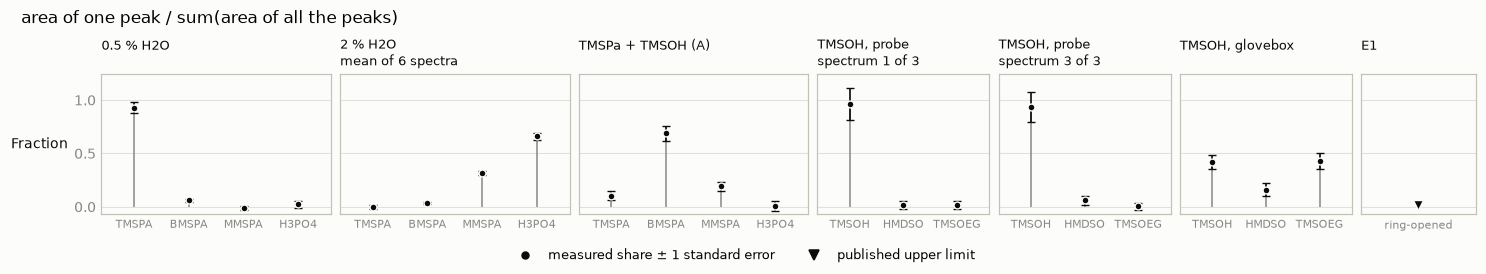

In [4]:
observables = load_lab_observables()
samples = describe_lab_observables(observables)
display(samples[samples['role'] == 'fit'][['spectra', 'solutes at t = 0', 'before the first spectrum', 'heated after the first spectrum']])
fit_plots.plot_compositions({'Fraction': fitted(MAIN)[1]}, PANELS[:3] + [('TMSOH, probe', 1), ('TMSOH, probe', 3)] + PANELS[4:],
                            predicted=False, title='area of one peak / sum(area of all the peaks)');

print('Standard error is considered noise')

| Fact | What is measured | Sample |
|---|---|---|
| **A** | TMSOH leaves EC alone at room temperature: at most 3 % ring-opened over six days, and less than 2 % in a week in the paper. At 80 °C it opens EC: 43 % ring-opened after 8 h | TMSOH probe, E1, TMSOH glovebox |
| **B** | TMSPA survives with 0.5 % water (93 % left) and is gone with 2 % water | the two water samples |
| **C** | The 2 % sample rests at 66 % H₃PO₄, 32 % MMSPA, 4 % BMSPA. Six spectra over 145 h show the same shares, heating steps up to 80 °C included | 2 % water |
| **D** | With TMSOH and no added water, 69 % of the phosphate is BMSPA and 19 % MMSPA: TMSOH removes TMS groups | TMSPA + TMSOH, tube A |

**How the 45 values are counted**

- **0.5 % water** 4, **tube A** 4, **TMSOH probe** 9 (three spectra), **TMSOH glovebox** 3, **E1** 1.
- **2 % water** 24: its six spectra count as one composition (4 values) and 20 measurements of "no change". Their scatter is 1.72 times what the spectral noise allows, so the error of these shares is multiplied by 1.72.
- **Kept out of the fit:** tube B (same recipe as tube A) and TMSPa without added water. They are used as checks in §4.7.
- **No sample was followed while it reacted.** Every share is a snapshot.

--> The models are compared with 45 numbers. 1.2 adds the unknown that every fit depends on.

### 1.2 The unknown age

- **Problem:** no mixing time is recorded. The age of a sample is the time from mixing to its first spectrum, and it is unknown for four of the five samples. Only the glovebox sample has a known history (8 h at 80 °C).
- **Way out:** every fit is made four times, each with a different assumption for the unknown ages.

| Name in the result files | Shown here as | Assumption |
|---|---|---|
| `short` | **1 h** | every sample was 1 h old at its first spectrum |
| `middle` | **1 day** | every sample was 1 day old |
| `long` | **7 days** | every sample was 7 days old |
| `free` | **free ages** | each age between 1 h and 7 days, chosen by the fit to favour the model |

- **How to use it:** a value that is the same under the four assumptions is set by the data. A value that changes with the assumed age is set by the assumption.

--> §1 hands to §2 the 45 values and the four assumed ages.

## 2. The ladder: from one barrier to nine parameters

**What this part delivers:** the simplest structure that the data do not reject, and the fact that rejects each simpler one.

- **Structure:** a model with its barrier values left free for the fit.
- **Ladder:** each structure adds freedom to the one before.

| Step | Structure | Free parameters | What it adds |
|---|---|---|---|
| 2.1 | M0 | 1 | one barrier for all nine reactions: the structure of `peter_reference` |
| 2.2 | M1 | 4 | one barrier per family: the structure of `level1` |
| 2.3 | M1-split | 5 | R1 separate from R2 and R3 |
| 2.4 | M3 | 8 | M1 with the reaction energies of R1–R4 free |
| 2.5 | M3-split | 9 | both additions together |

**How a fit is scored**

- **Miss:** $z = \dfrac{\text{predicted} - \text{measured}}{\text{standard error}}$. 1 or 2 is normal noise. Above 3 the model is wrong about that value.
- **Standard error of a share:** noise ⊕ baseline spread ⊕ a declared floor (³¹P: the larger of 0.01 and 5 %; ¹³C: the larger of 0.03 and 15 %).
- **Fit rule, fixed before any fit:** a structure fits if its worst miss, the largest of the 45 in absolute value, is 3 or less.
- **χ²:** the sum of the squared misses. The search makes it as small as it can (`kinetics.fitting.fit_structure`).

**How to read each step**

- **Table:** one row per assumed age (1 h, 1 day, 7 days, free ages: the unknown age of 1.2), with the best fit at that age. The first rows say which structure it is.
    - **χ²** and **worst miss:** as defined above. **fits:** yes if the worst miss is 3 or less.
    - **where the worst miss is:** the sample and the species of that value.
    - **ΔG‡ (eV):** the barrier each reaction ends up with. It is not the fitted parameter. The fit chooses the intrinsic barrier of a family (g, called E₀ in the capped-BEP form), and ΔG‡ follows from g and the reaction energy ΔG_rxn of each reaction. R1, R2, R3, R5 are given at 22 °C; R4 and R8 at 80 °C.
- **Figure:** the six panels of §1.1. Dot: measured. Bar: predicted at an assumed age of 1 day. A red bar is a miss above 3, with the miss written over it.

### 2.1 M0: one barrier for every reaction

- **Assumption:** every reaction of every family has the same intrinsic barrier. One free parameter.
- **Two forms:** capped BEP, which is the structure of `peter_reference`, and Marcus.
- **Figure, first row:** `peter_reference` as it is, with 1.15 eV. **Second row:** the best single barrier.

In [ ]:
print('Assumed age at first spectrum')
display(pd.concat({s: tables.format_rung_table(summary, barriers, s, AGES, SEEN) for s in ('M0-BEP', 'M0-Marcus')}))
print('Worst miss: each fit has 45 misses, one per measured value. The worst miss is the largest of them, ignoring the sign. In M0 it is 60, so one value is 60 standard errors away from its measurement.')
print('fits = ✗: the rule is "worst miss ≤ 3". 60 is above 3, so M0 does not fit.')
fit_plots.plot_compositions(dict([as_registered('peter_reference'), fitted('M0-BEP')]), PANELS, title='M0: one barrier for every reaction');

**Result**

- **At 1.15 eV (`peter_reference` as it is):** solvent attack is too fast and hydrolysis too slow at the same time. 62 % of the TMSOH opens an EC ring in a week at room temperature where the paper sees less than 2 % (miss 60). After one day the 2 % sample still holds 84 % of its TMSPA where none is measured (miss 50).
- **Best single barrier:** 1.28 eV in the capped-BEP form and 1.46–1.47 eV in the Marcus form, the same at every assumed age (χ² ≈ 3 630–3 690). In the capped-BEP form the glovebox sample is then within the rule (misses below 3), and nothing reacts at room temperature: every phosphate sample is predicted as 100 % TMSPA (miss 60 in the 2 % sample, 20 in tube A).
- **Why no value works: fact A against facts B and D.** Solvent attack needs about 1.29 eV to leave TMSOH alone at room temperature. Consuming TMSPA within days at room temperature needs about 1.1 eV or less.
- **Verdict:** the structure is rejected, not the value. 1.15 eV was chosen to spread the consumption of TMSPA over the holds of the protocol. It is a design value for planning the measurement and was never a fit.

--> One number cannot be slow for solvent attack and fast for hydrolysis. Next: one barrier per family.

### 2.2 M1: one barrier per family

- **Assumption:** each of the four families (hydrolysis, transfer, condensation, solvent attack) has its own Marcus barrier. Four free parameters. The reaction energies stay as computed.
- **Figure, first row:** `level1` as it is (hydrolysis and transfer at a placeholder of 0.80 eV). **Second row:** the four barriers fitted.

In [ ]:
print('Assumed age at first spectrum')
display(tables.format_rung_table(summary, barriers, 'M1', AGES, SEEN))
print('Worst miss: each fit has 45 misses, one per measured value. The worst miss is the largest of them, ignoring the sign. In M0 it is 60, so one value is 60 standard errors away from its measurement.')
print('fits = ✗: the rule is "worst miss ≤ 3". 60 is above 3, so M0 does not fit.')
fit_plots.plot_compositions(dict([as_registered('level1'), fitted('M1')]), PANELS, title='M1: one barrier per family');

**Result**

- **`level1` as it is:** the TMSOH samples are already described (no miss above 3 in the two ¹³C samples and E1), because its condensation and solvent-attack barriers came from the paper. The 0.80 eV placeholders finish hydrolysis in under a second: the 0.5 % sample is predicted as 90 % H₃PO₄ where 93 % TMSPA is measured (miss 30).
- **With the four barriers fitted:** the 0.5 % sample is matched, with ΔG‡(R1) at 1.18 eV for an age of 1 day. Solvent attack stays at 1.28 eV at every age. χ² falls from 1 264 to 343.
- **What still fails: fact C.** The 2 % sample is predicted as 100 % H₃PO₄ where 66 % H₃PO₄ and 32 % MMSPA are measured (misses +10 and −16). At 1 day HMDSO in the probe sample is also overpredicted (26 % against 6 %, miss 4.6).
- **Why no barrier can repair it:** a barrier sets how fast a reaction goes, not where it stops. The 2 % composition did not move in 145 h, so it is a resting state. With the computed energies hydrolysis can only rest at H₃PO₄.

--> M1 leaves two suspects: the single hydrolysis barrier shared by R1, R2 and R3, and the computed energies. 2.3 changes the first, 2.4 the second, 2.5 both.

### 2.3 M1-split: R1 separate from R2 and R3

- **Assumption:** as M1, but the first hydrolysis (R1) has its own barrier. R2 and R3 share a second one. Five free parameters. The reaction energies stay as computed.
- **Why split:** with one hydrolysis barrier, Marcus makes R1 the fastest of the three, because it is the most downhill. The samples ask for the opposite: TMSPA survives in the 0.5 % sample (R1 slow), and the 2 % sample is mostly H₃PO₄ (R2 and R3 not slow).
- **Why R2 and R3 stay together:** only the 2 % sample shows hydrolysis past BMSPA. One sample cannot fix two separate barriers.

In [ ]:
print('Assumed age at first spectrum')
display(tables.format_rung_table(summary, barriers, 'M1-split', AGES, SEEN))
print('Worst miss: each fit has 45 misses, one per measured value. The worst miss is the largest of them, ignoring the sign. In M0 it is 60, so one value is 60 standard errors away from its measurement.')
print('fits = ✗: the rule is "worst miss ≤ 3". 60 is above 3, so M0 does not fit.')
fit_plots.plot_compositions(dict([fitted('M1-split')]), PANELS, title='M1-split: R1 separate from R2 and R3');

**Result**

- **R1 comes out above R2 and R3 at every age** (1 day: 1.23 eV against 0.96 and 0.95 eV), which is what the split was for.
- **It helps little.** χ² falls from 343 to 301 at 1 day, and the HMDSO miss in the probe sample is gone. The worst miss stays at 15–16.
- **Why it still fails: fact C again.** The worst miss is MMSPA in the 2 % sample. The computed energies send R2 and R3 to the end, and no barrier can stop them partway.

--> A separate R1 is not enough on its own. Next, the other suspect: the energies.

### 2.4 M3: reaction energies of R1–R4 free

- **Assumption:** as M1 (one hydrolysis barrier), but the computed reaction energies of R1–R4 may be wrong by about their standard error, so the fit may move them. Eight free parameters.
- **Why only R1–R4:** the transfer energies (R5–R7) follow from them through the closed cycles. R8 and R9 keep their computed values, because no sample is seen at rest for them.
- **How an energy is held:** the computed value counts as one more measurement, "ΔG_rxn = computed ± standard error", so a shift is a miss like any other. This adds four values to the 45.
- **What it buys:** a reaction with ΔG_rxn near zero stops partway. That is what fact C needs.
- **Figure:** the best fit at 1 day and with free ages, because here the two differ.

In [ ]:
print('Assumed age at first spectrum')
display(tables.format_rung_table(summary, barriers, 'M3', AGES, SEEN))
print('Worst miss: each fit has 45 misses, one per measured value. The worst miss is the largest of them, ignoring the sign. In M0 it is 60, so one value is 60 standard errors away from its measurement.')
print('fits = ✗: the rule is "worst miss ≤ 3". 60 is above 3, so M0 does not fit.')
fit_plots.plot_compositions(dict([fitted('M3'), fitted('M3', 'free')]), PANELS, title='M3: reaction energies of R1–R4 free, one hydrolysis barrier');

**Result**

- **At 1 day nothing is gained** (χ² 294, worst miss 16.1). The 2 % sample is still predicted as 100 % H₃PO₄.
- **At 7 days and with free ages the resting state is reached.** With free ages the 2 % sample is predicted as 68 % H₃PO₄ and 32 % MMSPA. It has no BMSPA where 3.7 % is measured, a miss of 3.06: the structure fails by very little. At 7 days it fails through HMDSO in the probe sample (miss 4.1).
- **Reading:** free energies are what allow a reaction to stop partway. What still fails is the single hydrolysis barrier: R1 has to be slow (fact B) while R2 and R3 are not (fact C).

--> Each change fails on its own. Next: both together.

### 2.5 M3-split: both changes together

- **Assumption:** R1 separate from R2 and R3, and the reaction energies of R1–R4 free. Nine free parameters.

In [ ]:
print('Assumed age at first spectrum')
display(tables.format_rung_table(summary, barriers, MAIN, AGES, SEEN))
print('Worst miss: each fit has 45 misses, one per measured value. The worst miss is the largest of them, ignoring the sign. In M0 it is 60, so one value is 60 standard errors away from its measurement.')
print('fits = ✗: the rule is "worst miss ≤ 3". 60 is above 3, so M0 does not fit.')
fit_plots.plot_compositions(dict([fitted(MAIN), fitted(MAIN, 'free')]), PANELS, title='M3-split: R1 separate and reaction energies free');

**Result**

- **M3-split fits at 1 day, 7 days and with free ages:** χ² 20.4, 19.8 and 18.6, worst miss 1.9 in each.
- **Its worst miss is not a composition.** It is a "no change" value: TMSPA in the fourth spectrum of the 2 % sample. This is scatter among the six spectra, which no model can remove.
- **At 1 h it fails** (worst miss 11.6, TMSPA in tube A). One hour is not enough time for the samples to react as observed.
- **The four facts are reproduced** at 1 day and with free ages: every bar is within the error of its dot.

--> M3-split is the first structure that the data do not reject. 2.6 puts the whole ladder in one picture.

### 2.6 The ladder in one picture

- **Figure:** the worst miss of every structure at every assumed age. A structure fits where its point is inside the grey band.
- **Table:** the four structures built on M1, arranged by the two changes. A cell reads χ² (worst miss).

1 day                         \
                              energies as computed energies of R1–R4 free   
one hydrolysis barrier            M1: 343 (16.1) ✗       M3: 294 (16.1) ✗   
R1 separate from R2 and R3  M1-split: 301 (16.0) ✗   M3-split: 20 (1.9) ✓   

                                            7 days                         \
                              energies as computed energies of R1–R4 free   
one hydrolysis barrier            M1: 320 (16.0) ✗         M3: 60 (4.1) ✗   
R1 separate from R2 and R3  M1-split: 291 (15.4) ✗   M3-split: 20 (1.9) ✓   

                                         free ages                         
                              energies as computed energies of R1–R4 free  
one hydrolysis barrier            M1: 301 (16.0) ✗         M3: 27 (3.1) ✗  
R1 separate from R2 and R3  M1-split: 282 (15.0) ✗   M3-split: 19 (1.9) ✓

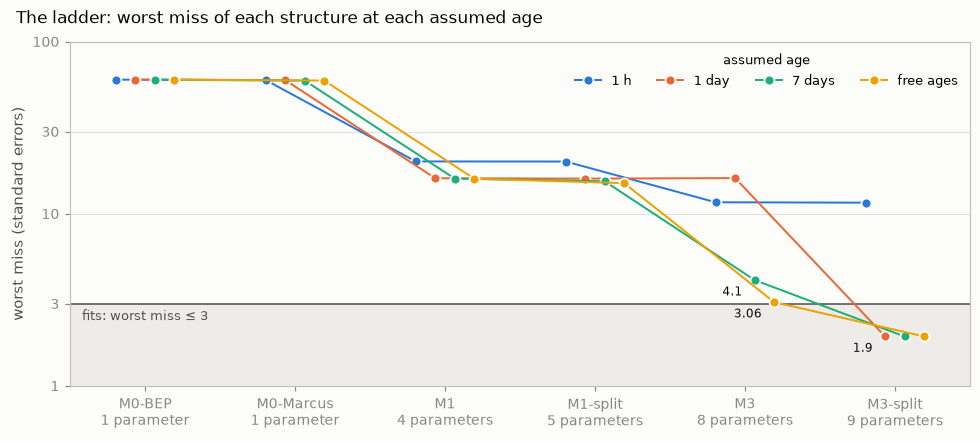

In [8]:
fit_plots.plot_ladder(summary, order=LADDER);
score = summary.set_index(['structure', 'scenario'])
grid = {'one hydrolysis barrier': {'energies as computed': 'M1', 'energies of R1–R4 free': 'M3'},
        'R1 separate from R2 and R3': {'energies as computed': 'M1-split', 'energies of R1–R4 free': 'M3-split'}}
pd.DataFrame({(AGES[sc], energies): {hydrolysis: f"{row[energies]}: {score.loc[(row[energies], sc), 'chi2']:.0f} ({score.loc[(row[energies], sc), 'max |z|']:.1f})"
                                     + (' ✓' if score.loc[(row[energies], sc), 'fits'] else ' ✗') for hydrolysis, row in grid.items()}
              for sc in FITTING for energies in ('energies as computed', 'energies of R1–R4 free')})

**Result**

| Structure | Free parameters | Fits? | Rejected by |
|---|---|---|---|
| M0 | 1 | no | fact A against B and D: one barrier cannot be slow for solvent attack and fast for hydrolysis |
| M1 | 4 | no | fact C: the computed energies send hydrolysis to the end |
| M1-split | 5 | no | fact C again: separating R1 does not help on its own |
| M3 | 8 | no, by little with free ages | facts B and C together: one hydrolysis barrier cannot serve R1 and R2–R3 |
| M3-split | 9 | yes, at 1 day, 7 days and free ages | — |

- **Both changes are needed together.** At 1 day the split alone gives 301 (16.0), free energies alone 294 (16.1), both 20 (1.9).
- **With free ages the split matters least.** Free energies alone miss the rule by 0.06 (worst miss 3.06). The need for a separate R1 rests on the assumed ages (§4.6).
- **The test is weak.** Nine parameters are matched to about 17 independent compositions (each spectrum gives one share less than it has peaks). Of the χ² of about 20, about 18 is the scatter of the 2 % spectra (§4.4).
- **By the rule fixed before fitting,** the first consistent set is the smallest structure that fits, at a common age before free ages: M3-split at 7 days (χ² 19.8) or at 1 day (20.4). The data cannot tell the two apart.

--> Only M3-split fits. §3 looks at what it had to assume to do so.

## 3. What the fitting model found

**What this part delivers:** the barriers and the reaction energies of M3-split at the three ages where it fits, and the way each age consumes TMSPA.

### 3.1 Barriers

- **Why ΔG‡ and not g:** ΔG‡ is what sets the rate, so it is what the data act on. The intrinsic barrier g follows from it through the Marcus relation and the reaction energy.
- **The ruler:** the upper scales translate a barrier into a half-life with the reaction partner at 1 M. At 22 °C a half-life of one second is 0.76 eV and one of ten years is 1.26 eV, and +0.06 eV makes a reaction 10 times slower.
- **Where each barrier was seen:** hydrolysis and transfer at 22 °C, condensation and solvent attack at 80 °C.

ΔG‡ (eV),1 day,7 days,free ages
reaction,,,
R1,1.45,1.39,1.09
R2,0.95,1.01,1.04
R3,0.97,1.03,1.06
R5,0.58,0.61,0.89
R4,1.24,1.24,1.24
R8,1.29,1.29,1.29


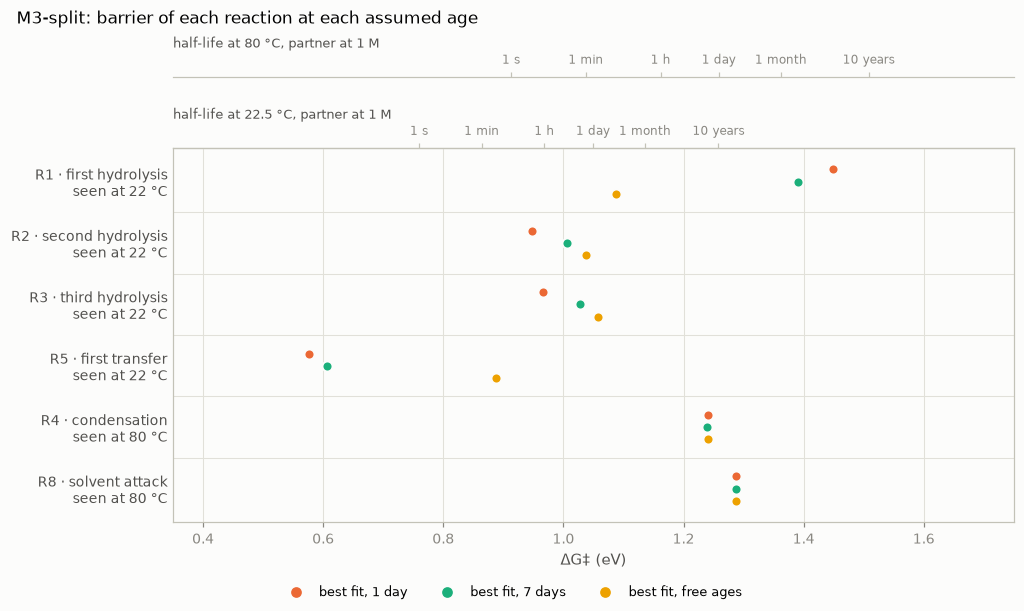

In [9]:
main = barriers[(barriers['structure'] == MAIN) & barriers['reaction'].isin(SEEN)]
display(by_age(main.pivot(index='reaction', columns='scenario', values='dG_barrier_eV')).loc[list(SEEN)].round(2).rename_axis(columns='ΔG‡ (eV)'))
fit_plots.plot_barrier_ruler(barriers, structure=MAIN, scenarios=FITTING);

**Result**

- **The same at every age:** solvent attack, ΔG‡(R8) = 1.29 eV; condensation, ΔG‡(R4) = 1.24 eV; second and third hydrolysis, ΔG‡(R2) = 0.95–1.04 eV and ΔG‡(R3) = 0.97–1.06 eV.
- **Different at every age:** first hydrolysis, ΔG‡(R1) = 1.45, 1.39 and 1.09 eV; transfer, ΔG‡(R5) = 0.58, 0.61 and 0.89 eV.
- **On the ruler (partner at 1 M):** at 1 day and 7 days R1 has a half-life of thousands of years and transfer one of milliseconds. With free ages R1 has a half-life of days and transfer one of minutes. These are two different mechanisms (3.3).

--> Four barriers do not depend on the assumed age; two do. Before asking why, 3.2 shows what happened to the energies.

### 3.2 Reaction energies

- **Table and figure:** the computed ΔG_rxn of R1–R4 with its standard error, the fitted value at each age, and the shift counted in standard errors.

computed (eV)                  fitted ΔG_rxn (eV)                   \
                ΔG_rxn ± standard error              1 day 7 days free ages   
reaction                                                                      
R1               -0.47             0.26              -0.09  -0.12     -0.04   
R2               -0.16             0.25              -0.01  -0.04      0.05   
R3               -0.18             0.24               0.03   0.01      0.09   
R4                0.10             0.34              -0.06   0.01     -0.18   

         shift (standard errors)                   
                           1 day 7 days free ages  
reaction                                           
R1                          1.48   1.37      1.66  
R2                          0.62   0.50      0.86  
R3                          0.86   0.76      1.11  
R4                         -0.47  -0.26     -0.84

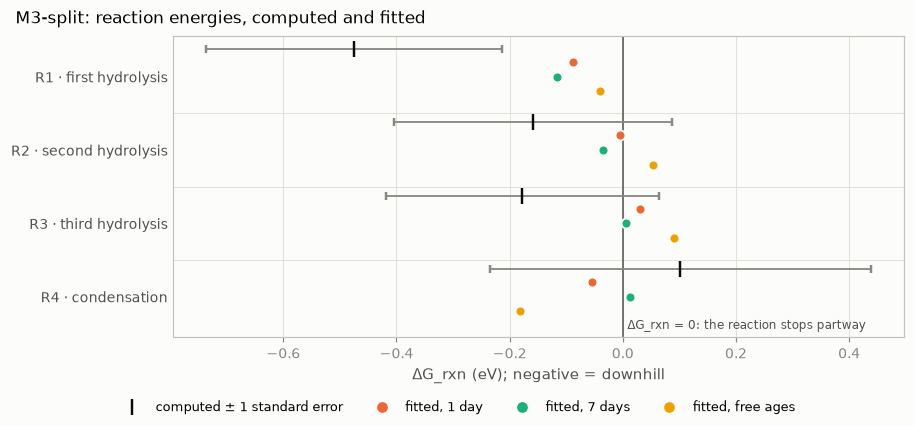

In [10]:
computed = barriers[(barriers['structure'] == 'M1') & (barriers['scenario'] == 'middle')].set_index('reaction')['dG_rxn_eV']   # M1 keeps the computed energies
pulls = residuals[(residuals['structure'] == MAIN) & (residuals['kind'] == 'prior')]
pulls = pulls.assign(reaction=pulls['quantity'].str.extract(r'\((R\d)\)')[0])
sigma = pulls.groupby('reaction')['sigma'].first()
display(pd.concat({'computed (eV)': pd.DataFrame({'ΔG_rxn': computed, '± standard error': sigma}),
                   'fitted ΔG_rxn (eV)': by_age(main.pivot(index='reaction', columns='scenario', values='dG_rxn_eV')),
                   'shift (standard errors)': by_age(pulls.pivot(index='reaction', columns='scenario', values='z'))}, axis=1).loc[['R1', 'R2', 'R3', 'R4']].round(2))
fit_plots.plot_energy_shifts(barriers, structure=MAIN, computed=computed.to_dict(), sigma=sigma.to_dict(), scenarios=FITTING);

**Result**

- **R2 and R3 move up to about zero:** R2 from −0.16 eV to between −0.04 and +0.05 eV, R3 from −0.18 eV to between +0.01 and +0.09 eV. A reaction with ΔG_rxn near zero stops partway. This gives the resting composition of the 2 % sample (fact C).
- **R1 moves most:** from −0.47 eV to between −0.12 and −0.04 eV. **R4 moves down:** from +0.10 eV to between −0.18 and +0.01 eV.
- **No shift is larger than 1.7 standard errors.** The fit does not contradict the computed energies; it uses the room their uncertainty leaves.
- **Not moved:** R5–R7 follow from R1–R4 through the closed cycles. R8 and R9 keep their computed values.

--> The energies explain where the 2 % sample stops. 3.3 turns to the two barriers that change with the age.

### 3.3 Two ways to consume TMSPA

- **Question:** fact B says TMSPA is still there with 0.5 % water and gone with 2 %. How does a fit serve both samples?
- **Figure:** the TMSPA share of the two water samples from the moment of mixing, for the best fit at each age. The dots are the measured shares, placed at the age the fit assumes.

hours from mixing until half of the TMSPA is gone,1 day,7 days,free ages
sample,,,
0.5 % H2O,46.1,222.5,124.5
2 % H2O,12.8,59.1,29.2


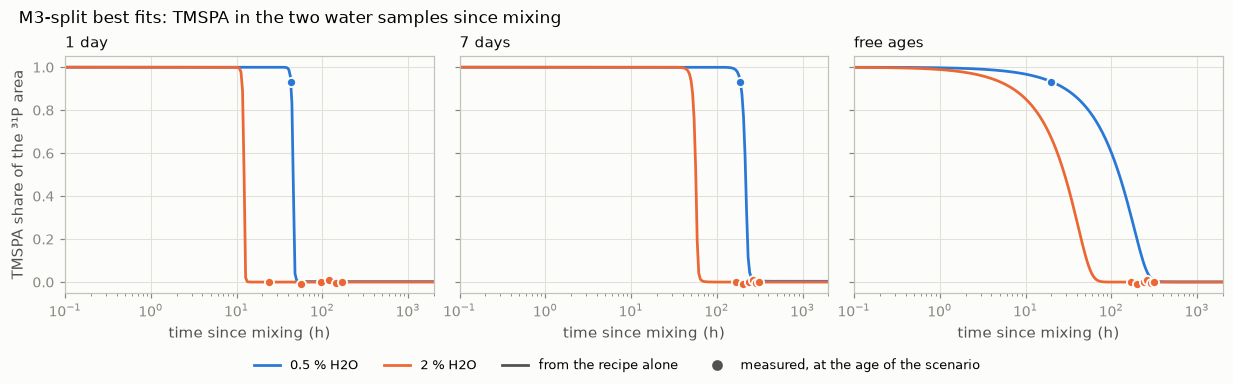

In [11]:
trajectories = read('sample_trajectories.csv')
fit_plots.plot_sample_trajectories(trajectories, structure=MAIN, scenarios=FITTING, labels=fit_plots.AGE_LABELS, with_trace=False);
clean = trajectories[(trajectories['kind'] == 'model') & (trajectories['TMSOH at mixing (M)'] == 0) & (trajectories['TMSPA'] < 0.5)]
by_age(clean.groupby(['sample', 'scenario'])['t_h'].min().unstack('scenario')).round(1).rename_axis(columns='hours from mixing until half of the TMSPA is gone')

**Result**

- **At a common age (1 day, 7 days): a waiting time, then a cliff.**
  - TMSPA does not hydrolyse on its own (k₁ ≈ 10⁻¹² to 10⁻¹¹ M⁻¹ s⁻¹). It is consumed by TMSOH through transfer.
  - Each TMSPA consumed gives back two TMSOH when BMSPA and MMSPA hydrolyse, so TMSOH multiplies.
  - Nothing is visible for hours, then TMSPA is gone within one. In the 1-day fit: after 13 h with 2 % water and 46 h with 0.5 %.
  - The 2 % sample is then read after its cliff and the 0.5 % sample 3 h before its own.
- **With free ages: ordinary kinetics.** R1 at 1.09 eV consumes TMSPA smoothly, four times faster with 2 % water than with 0.5 %. The fit puts the 2 % sample at the 7-day limit and the 0.5 % sample at the 1 h limit.
- **This is why R1 and R5 change with the age.** The cliff needs R1 frozen and transfer fast. The smooth decay needs R1 near 1.1 eV and a slower transfer.

--> Two different mechanisms fit the same 45 values. §4 asks which parts of the result hold when what was assumed is changed.

## 4. Stress tests: which parts of the result hold

**What this part delivers:** for each fitted value, whether it stays when something that was assumed is changed.

| Step | Question | What is changed |
|---|---|---|
| 4.1 | Does the search find a known answer? | the lab shares are replaced by shares made from known parameters |
| 4.2 | Were the samples clean? | a trace of TMSOH is added at mixing |
| 4.3 | How wide is each value? | one parameter is moved away from its best value until the fit gets worse |
| 4.4 | Which sample decides each value? | one sample is left out |
| 4.5 | Equilibrium, or did the water run out? | part of the added water is made unavailable |
| 4.6 | Do the declared choices matter? | error floor, energy errors, heating times, barrier relation |
| 4.7 | Does it agree with data the fit did not use? | tube B, TMSPa without added water, the paper |
| 4.8 | Scorecard | every barrier against every test |

### 4.1 Does the search find a known answer?

- **Test:** shares are generated from a known parameter set with the lab design (same samples, times and errors), noise is added, and the fit has to find the parameters again.
- **Cases:** A is M1-split (three noise draws). B is M3-split with ΔG_rxn of R2 and R3 moved by +0.12 and +0.17 eV (two noise draws).
- **Figure:** per parameter, the 95 % interval of each case against the value that made the data.

,χ² of the fit,χ² of the true parameters,true values inside their interval,intervals
case,,,,
"A, seed 1",21.8,24.9,5,5
"A, seed 2",24.3,29.1,5,5
"A, seed 3",35.8,42.8,5,5
"B, seed 1",23.2,27.5,7,7
"B, seed 2",27.8,31.7,6,7


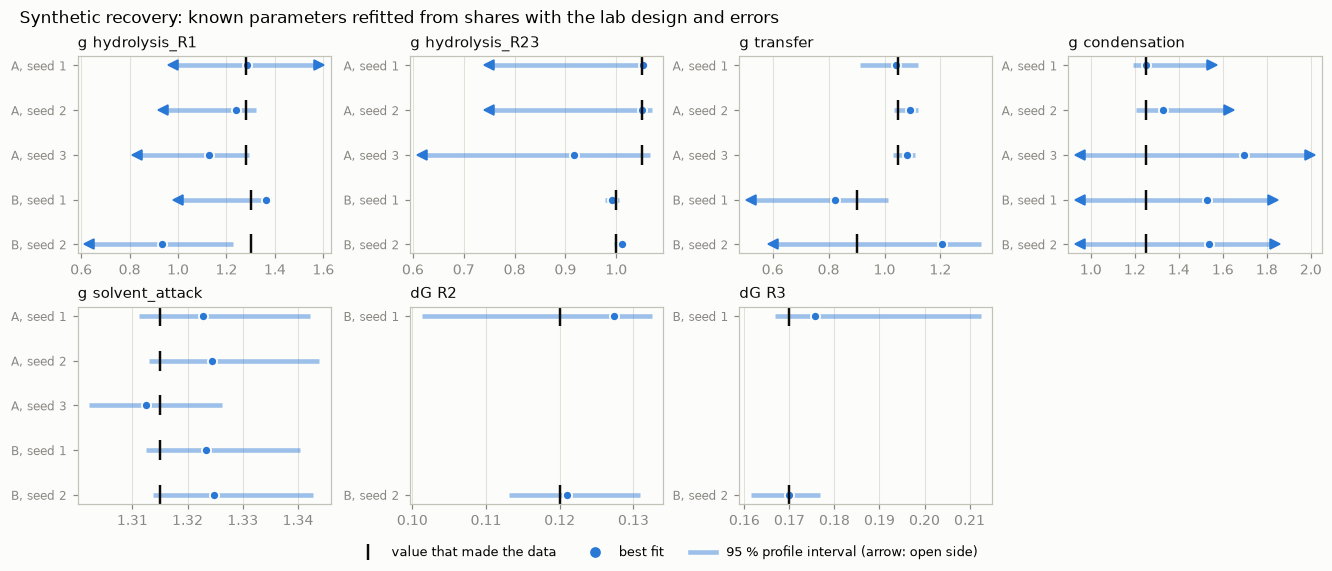

In [12]:
recovery = read('recovery_summary.csv')
display(recovery.groupby('case').agg(**{'χ² of the fit': ('chi2 fit', 'first'), 'χ² of the true parameters': ('chi2 truth', 'first'),
                                        'true values inside their interval': ('truth inside', 'sum'), 'intervals': ('truth inside', 'size')}).round(1))
fit_plots.plot_recovery(recovery);

**Result**

- **The search finds the optimum.** In all five cases the fit reaches a χ² below that of the true parameters.
- **The intervals are honest.** 28 of the 29 true values lie inside their 95 % interval. The one outside is the R1 barrier in one case B, where the fit settled in another basin.
- **Determined when the model is right:** the solvent-attack barrier (about ±0.015 eV every time), and in case B the barrier and the energies of R2 and R3 (±0.01–0.02 eV).
- **Not determined even when the model is right:** the R1 barrier gets an upper bound at most, condensation a lower bound or nothing, transfer an upper bound in case B.

**Verdict:** the method works. A "not determined" for R1 or for condensation is a property of the samples that exist, not a failure of the fit.

--> The search can be trusted. The next tests are about the assumptions.

### 4.2 Were the samples clean? A trace of TMSOH at mixing

- **What was assumed:** every sample starts from its recipe alone, with no TMSOH at mixing.
- **Why doubt it:** the first spectrum of TMSPa without added water already shows 12 ± 5 % BMSPA, and the 0.5 % sample 6 %. Each hydrolysed phosphate has released a silyl group, so TMSOH or HMDSO at the millimolar level at mixing is the likely case.
- **Test 1:** each fit is kept as it is and TMSOH is added at mixing, from 1 nM to 1 mM.
- **Test 2:** the fit is made again with 1 µM and with 1 mM in place.
- **First figure:** the trajectories of 3.3, with 1 µM of TMSOH at mixing as dashed lines. **Second figure:** the worst miss against the size of the trace.

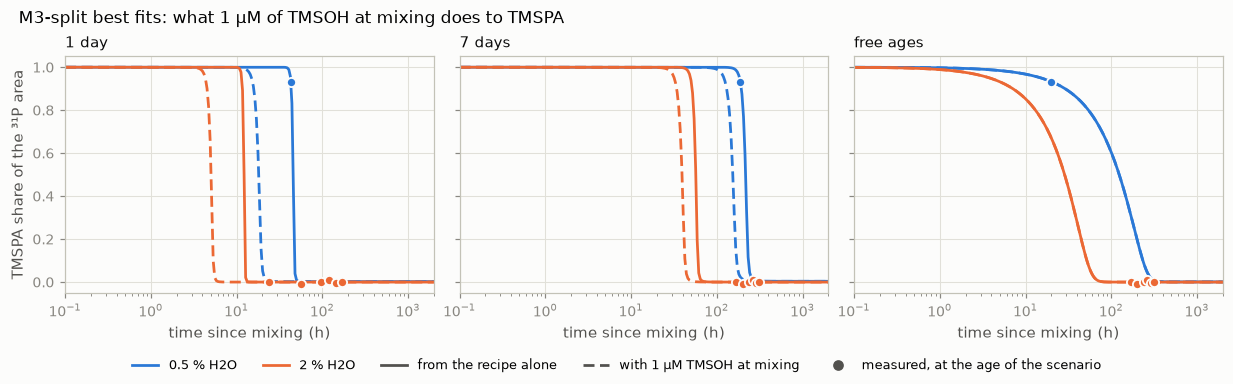

In [13]:
fit_plots.plot_sample_trajectories(trajectories, structure=MAIN, scenarios=FITTING, labels=fit_plots.AGE_LABELS,
                                   title=f'{MAIN} best fits: what 1 µM of TMSOH at mixing does to TMSPA');

χ² of the fit as it is,1 day,7 days,free ages
TMSOH at mixing,,,
none,20.4,19.8,18.6
1 nM,372.9,19.8,18.6
100 nM,1112.3,269.8,18.6
1 µM,1110.9,1542.2,18.6
10 µM,1110.8,1306.0,18.6
100 µM,1110.8,1257.8,18.6
1 mM,1110.7,1237.3,18.9


χ²  worst miss   fits  ΔG‡ R1  ΔG‡ R2  \
fitted again with assumed age                                             
1 µM              1 day        28.18        2.50   True    1.24    0.95   
                  7 days       21.08        1.93   True    1.36    1.01   
                  free ages    18.59        1.93   True    1.09    1.04   
1 mM              1 day        37.34        3.86  False    1.30    0.98   
                  7 days       23.13        2.00   True    1.69    1.04   
                  free ages    18.70        1.93   True    1.09    1.04   

                               ΔG‡ R3  ΔG‡ R5  ΔG‡ R4  ΔG‡ R8  
fitted again with assumed age                                  
1 µM              1 day          0.97    0.89    1.24    1.29  
                  7 days         1.03    0.58    1.24    1.29  
                  free ages      1.06    0.89    1.24    1.29  
1 mM              1 day          1.00    0.78    1.24    1.29  
                  7 days         1.06    0.67    1.24    1.29  
                  free ages      1.06    0.87    1.24    1.29

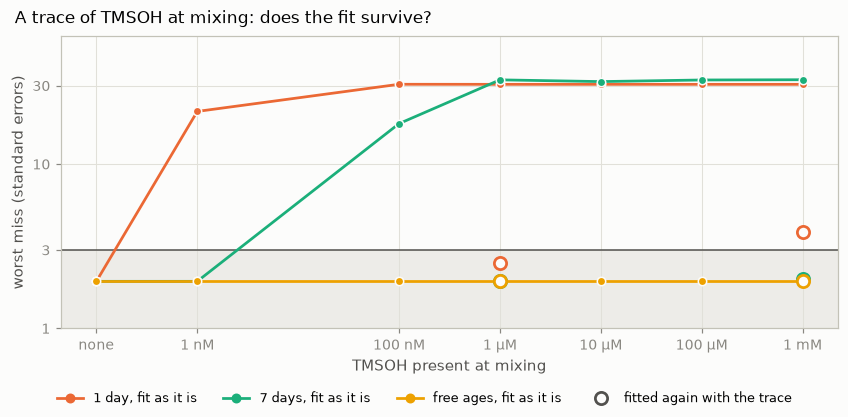

In [14]:
traces = read('trace_sensitivity.csv').assign(trace=lambda d: d['TMSOH at mixing (M)'].map(show_M))
fit_plots.plot_trace_scan(traces, scenarios=FITTING);
display(by_age(traces[traces['parameters'] == 'as fitted without it'].pivot_table(index='trace', columns='scenario', values='chi2', sort=False)).round(1)
        .rename_axis(index='TMSOH at mixing', columns='χ² of the fit as it is'))
again = traces[traces['parameters'] == 'fitted again'].assign(age=lambda d: d['scenario'].map(AGES))
again.set_index(['trace', 'age'])[['chi2', 'max |z|', 'fits'] + BARRIERS].round(2).rename(columns={'chi2': 'χ²', 'max |z|': 'worst miss'}).rename(
    columns=lambda c: c.replace('dG‡', 'ΔG‡')).rename_axis(index=['fitted again with', 'assumed age'])

**Result**

- **The cliff is timed by what starts it.** With no TMSOH in the recipe, the start is what R1 makes in the first 37 min: about 0.4 nM. Adding 1 nM at mixing takes the 1-day fit from χ² 20 to 373. With 100 nM the 7-day fit goes to 270.
- **Fitted again with a trace, a common age can still fit, with other barriers.** With 1 µM both common ages fit (χ² 28.2 and 21.1). With 1 mM the 7-day fit does (23.1) and the 1-day fit does not (worst miss 3.9). ΔG‡(R1) then lies anywhere from 1.24 to 1.69 eV and ΔG‡(R5) from 0.58 to 0.89 eV.
- **The free-age fit does not depend on a trace:** χ² 18.6 from none to 0.1 mM, 18.7 when fitted again with 1 mM, barriers unchanged within 0.015 eV.

**Verdict**

- **Holds:** ΔG‡ of R8, R4, R2 and R3, the same with or without a trace.
- **Does not hold:** ΔG‡ of R1 and R5 at a common age. They are set by the assumed trace, not by the data.

--> The common-age fits rest on a mechanism that a trace removes. This is why no model was registered.

### 4.3 How wide is each value?

- **Test:** one parameter is moved away from its best value in steps, and all the others are fitted again at each step. The 95 % interval ends where χ² has risen by 3.84.
- **Accepted sets:** all the parameter sets met inside these intervals.
- **Figure:** the ruler of 3.1, with a bar for the range of each ΔG‡ over the accepted sets. **Table:** the same ranges, and those of ΔG_rxn.

ΔG‡ over the accepted sets (eV)                        \
assumed age                           1 day     7 days  free ages   
reaction                                                            
R1                                1.23–1.59  1.19–1.65  1.08–1.14   
R2                                0.93–0.98  0.97–1.05  0.99–1.05   
R3                                0.95–1.00  0.99–1.06  1.00–1.07   
R5                                0.42–0.73  0.41–0.86  0.59–0.99   
R4                                1.22–1.28  1.23–1.26  1.23–1.25   
R8                                1.28–1.30  1.29–1.29  1.28–1.30   

            ΔG_rxn over the accepted sets (eV)                                  
assumed age                              1 day          7 days       free ages  
reaction                                                                        
R1                              -0.13 to +0.17  -0.13 to +0.18  -0.15 to +0.18  
R2                              -0.04 to +0.26  -0.04 to +0.27  -0.05 to +0.27  
R3                              +0.00 to +0.29  -0.00 to +0.31  +0.01 to +0.31  
R5                              -0.41 to -0.09  -0.43 to -0.09  -0.44 to -0.12  
R4                              -0.58 to +0.03  -0.61 to +0.04  -0.61 to +0.01  
R8                              -0.05 to -0.05  -0.05 to -0.05  -0.05 to -0.05

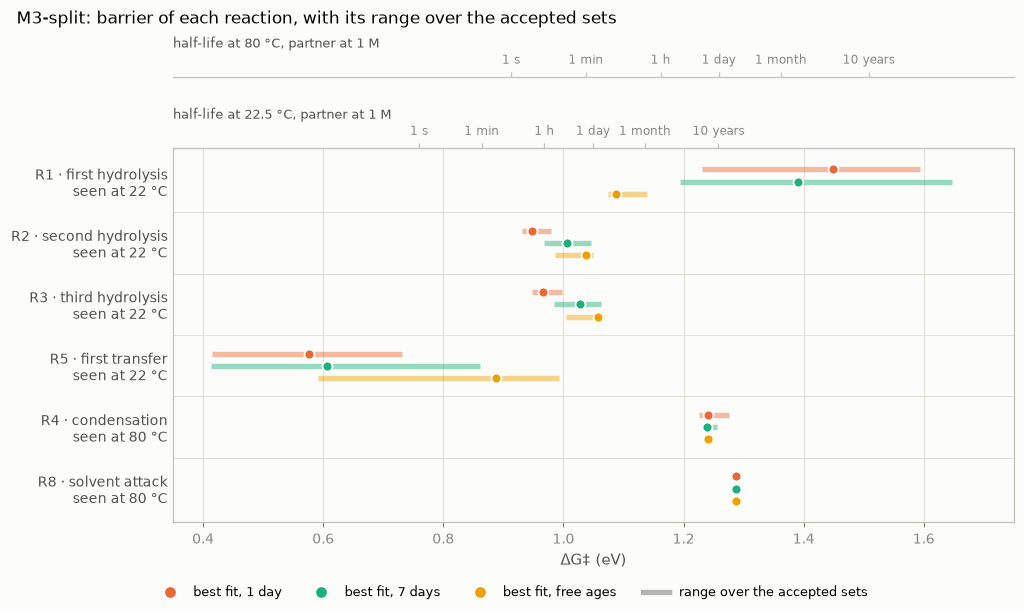

In [15]:
bands = read('barrier_bands.csv')
fit_plots.plot_barrier_ruler(barriers, bands, structure=MAIN, scenarios=FITTING, title=f'{MAIN}: barrier of each reaction, with its range over the accepted sets');
band = bands[bands['structure'] == MAIN]
band = band.assign(barrier=[f'{lo:.2f}–{hi:.2f}' for lo, hi in zip(band['dG‡ low'], band['dG‡ high'])],
                   energy=[f'{lo:+.2f} to {hi:+.2f}' for lo, hi in zip(band['dG_rxn low'], band['dG_rxn high'])])
pd.concat({'ΔG‡ over the accepted sets (eV)': by_age(band.pivot(index='reaction', columns='scenario', values='barrier')),
           'ΔG_rxn over the accepted sets (eV)': by_age(band.pivot(index='reaction', columns='scenario', values='energy'))}, axis=1).loc[list(SEEN)]

**Result**

- **Narrow at every age:** solvent attack 1.28–1.30 eV, condensation 1.22–1.28 eV, R2 0.93–1.05 eV, R3 0.95–1.07 eV.
- **Wide:** R1 spans 1.23–1.59 eV (1 day), 1.19–1.65 eV (7 days) and 1.08–1.14 eV (free ages). Transfer spans 0.42–0.73, 0.41–0.86 and 0.59–0.99 eV.
- **The energies of R2 and R3 exclude their computed values.** Over the accepted sets ΔG_rxn(R2) lies between −0.05 and +0.27 eV (computed −0.16) and ΔG_rxn(R3) between 0.00 and +0.31 eV (computed −0.18). This holds if all the added water was available (4.5).
- **Ages:** with free ages the 2 % sample is at least 50 h old at its first spectrum (A.3).
- **Every range is conditional** on its assumed age and on samples that start from the recipe alone (4.2).

**Verdict:** four barriers are narrow at every age. R1 and R5 are wide. For R1 the range with free ages (1.08–1.14 eV) lies outside the ranges at a common age (1.19 eV and above).

--> The ranges say how well a value is held. 4.4 asks which sample holds it.

### 4.4 Which sample decides each value?

- **Test:** the fit of M3-split is repeated without each sample in turn.
- **Figures:** how far ΔG‡ of each reaction moves (in meV) when a sample is left out, at 1 day and with free ages. **Table:** χ² and the worst miss without the sample.

χ² without the sample                   \
assumed age                       1 day 7 days free ages   
left out                                                   
0.5 % H2O                          19.4   17.3      16.8   
2 % H2O                             2.3    2.1       2.4   
E1                                 20.4   20.8      18.6   
TMSOH, glovebox                    18.1   18.7      16.1   
TMSOH, probe                       17.1   17.9      15.2   
TMSPa + TMSOH (A)                  17.2   17.4      14.8   

                  worst miss without the sample                   
assumed age                               1 day 7 days free ages  
left out                                                          
0.5 % H2O                                  1.93   1.93      1.93  
2 % H2O                                    0.78   0.79      0.78  
E1                                         1.93   1.93      1.93  
TMSOH, glovebox                            1.93   1.96      1.93  
TMSOH, probe                               1.93   1.93      1.93  
TMSPa + TMSOH (A)                          1.93   1.93      1.93

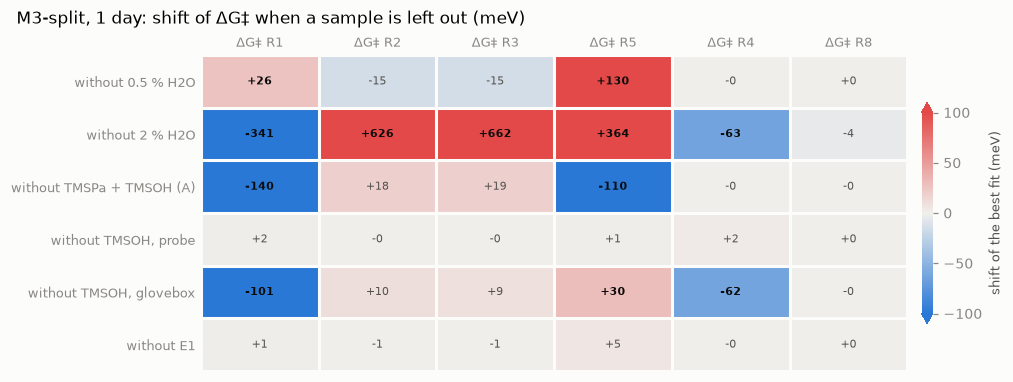

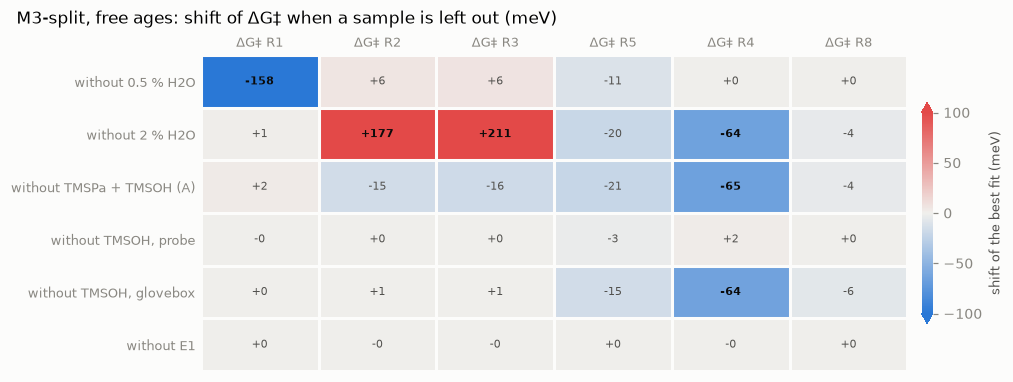

In [16]:
loo = read('leave_one_out.csv')
loo = loo[loo['structure'] == MAIN]
best = barriers[barriers['structure'] == MAIN].pivot(index='scenario', columns='reaction', values='dG_barrier_eV')
for scenario in ('middle', 'free'):
    fit_plots.plot_influence(loo[loo['scenario'] == scenario], {c: best.loc[scenario, c.split(' ')[1]] for c in BARRIERS}, columns=BARRIERS,
                             title=f'{MAIN}, {AGES[scenario]}: shift of ΔG‡ when a sample is left out (meV)')
pd.concat({'χ² without the sample': by_age(loo.pivot(index='left out', columns='scenario', values='chi2')).round(1),
           'worst miss without the sample': by_age(loo.pivot(index='left out', columns='scenario', values='max |z|')).round(2)}, axis=1)

**Result**

- **The 2 % water sample carries χ² and the barriers of R2 and R3.** Without it χ² falls from about 20 to 2.1–2.4, and ΔG‡(R2) runs up to 1.2–1.6 eV. It is the only sample in which hydrolysis is seen past BMSPA.
- **The 0.5 % water sample sets R1.** Without it ΔG‡(R1) falls by 0.16 eV with free ages (1.09 to 0.93 eV). At 7 days it falls from 1.39 to 0.98 eV: the waiting time of 3.3 is there because of this one spectrum.
- **Tube A sets transfer at a common age:** ΔG‡(R5) falls by 0.11 eV at 1 day without it.
- **Condensation moves when any of three samples is left out.** ΔG‡(R4) falls by about 0.06 eV, from 1.24 to 1.18 eV, without the glovebox sample or without the 2 % sample at every age, and without tube A with free ages.
- **The probe sample and E1 move nothing at 1 day and with free ages** (at most 0.005 eV). What they say about solvent attack is also said by the glovebox sample. At 7 days ΔG‡(R5) moves by 0.06 eV without either, well inside its range of 4.3.
- **Every fit without one sample still fits** (worst miss 1.96 at most), so no sample contradicts the others.

**Verdict**

- **Solvent attack** is the only barrier that no single sample moves: two samples check it independently.
- **R2 and R3** rest on the 2 % sample alone.
- **R1** rests on the 0.5 % sample with free ages. At a common age it moves when almost any sample is left out.
- **Condensation** needs three samples together to stay at 1.24 eV.

--> Each value has few samples behind it. 4.5 turns to the second explanation of fact C.

### 4.5 Equilibrium, or did the water run out?

- **Question:** 3.2 explains the resting 2 % sample by R2 and R3 being close to thermoneutral. There is a second explanation: part of the added water did not take part, and hydrolysis stopped when the available water was used up. No spectrum measures water.
- **Test:** one more parameter, the available fraction of the added water, is given to M3-split and to M1-split (which keeps the computed energies).
- **Table:** the fits with this parameter ("+W"), on the lab shares and on shares made by the other structure. **Figure:** how χ² of M3-split changes along the available fraction.

χ²  worst miss   fits  \
age       fitted     data                                           
1 day     M3-split+W lab                 20.38        1.93   True   
          M1-split+W lab                 82.12        7.11  False   
                     made by M3-split    67.81        6.86  False   
          M3-split   made by M1-split+W  11.25        1.56   True   
free ages M3-split+W lab                 18.21        1.93   True   
          M1-split+W lab                 78.69        7.07  False   
                     made by M3-split    65.44        6.89  False   
          M3-split   made by M1-split+W   5.03        1.57   True   

                                         water fraction  
age       fitted     data                                
1 day     M3-split+W lab                           1.00  
          M1-split+W lab                           0.21  
                     made by M3-split              0.21  
          M3-split   made by M1-split+W             NaN  
free ages M3-split+W lab                           0.69  
          M1-split+W lab                           0.21  
                     made by M3-split              0.21  
          M3-split   made by M1-split+W             NaN

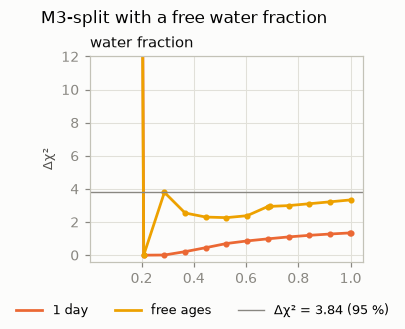

In [17]:
same = read('indistinguishability.csv').assign(age=lambda d: d['scenario'].map(AGES))
shown = {'chi2': 'χ²', 'max |z|': 'worst miss', 'within 3 SE': 'fits'}
display(same[same['question'] == 'equilibrium or exhausted water'].set_index(['age', 'fitted', 'data'])[list(shown) + ['water fraction']].rename(columns=shown).round(2))
water = {scenario: load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}+W__{scenario}.json'))['profile'] for scenario in ('middle', 'free')}
fit_plots.plot_profiles(water, ['water fraction'], title='M3-split with a free water fraction', labels=fit_plots.AGE_LABELS);

**Result**

- **Inside M3-split, any available fraction from 0.2 to 1 fits.** Over that range χ² changes by at most 1.3 (1 day) and 3.8 (free ages). Below 0.2 nothing fits.
- **The lowest point is at 0.21 at both ages** (figure). The direct fit of the table stopped at 1.00 and 0.69; stepping along the fraction found the slightly lower χ² at 0.21.
- **At 0.21 the energies of R2 and R3 need to move much less.** At 1 day their shifts fall to +0.08 and +0.13 eV (from +0.15 and +0.21). With free ages they fall to about zero (−0.05 and +0.01 eV, from +0.21 and +0.27).
- **Water running out with all the computed energies is not enough.** M1-split with a free fraction falls from χ² 301 to 82 (1 day) and from 282 to 79 (free ages), and still misses MMSPA in the 2 % sample by 7.
- **M3-split absorbs either explanation.** It fits shares made by the exhausted-water structure (worst miss 1.6). The reverse fails (6.9).

**Verdict:** not decided. "R2 and R3 are close to thermoneutral" holds only if all the added water was available.

--> Fact C has two explanations that these samples cannot separate. 4.6 checks the choices that were declared rather than measured.

### 4.6 Do the declared choices matter?

- **What was declared, not measured:** the error floor of a share, the standard errors of the computed energies, the 18 min of each heating step of the 2 % sample, the 8 h of the glovebox hold, and the Marcus form of the barrier relation.
- **Test:** the fit of M3-split is repeated with each choice changed.
- **First table:** each variant, with the largest shift of a barrier against the main fit. **Second table:** two questions about the structure itself.

In [18]:
sensitivities = read('sensitivities.csv')
reference = sensitivities[sensitivities['variant'] == 'as fitted'].set_index('scenario')[BARRIERS]
shift = sensitivities[BARRIERS] - reference.loc[sensitivities['scenario']].to_numpy()
declared = sensitivities.assign(age=sensitivities['scenario'].map(AGES),
                                **{'largest shift of a barrier (eV)': [f"{shift.loc[i, c]:+.3f} ({c.split(' ')[1]})" for i, c in shift.abs().idxmax(axis=1).items()]})
display(declared.set_index(['age', 'variant'])[['chi2', 'max |z|', 'fits', 'worst', 'largest shift of a barrier (eV)']].round(2)
        .rename(columns={'chi2': 'χ²', 'max |z|': 'worst miss', 'worst': 'where the worst miss is'}))
same[same['question'] != 'equilibrium or exhausted water'].set_index(['question', 'age', 'fitted', 'data'])[list(shown)].rename(columns=shown).round(2)

χ²  worst miss   fits  \
age       variant                                     
1 day     as fitted        20.38        1.93   True   
          floor x0         38.91        3.47  False   
          floor x2         17.74        1.93   True   
          covariance x0.5  24.66        2.07   True   
          covariance x2    18.19        1.93   True   
          ramp held 8 h    28.67        2.48   True   
          glovebox 4 h     20.02        1.93   True   
          glovebox 16 h    20.67        1.93   True   
free ages as fitted        18.59        1.93   True   
          floor x0         37.80        3.51  False   
          floor x2         15.65        1.93   True   
          covariance x0.5  22.82        2.30   True   
          covariance x2    16.39        1.93   True   
          ramp held 8 h    18.87        1.93   True   
          glovebox 4 h     18.01        1.93   True   
          glovebox 16 h    19.03        1.93   True   

                                            where the worst miss is  \
age       variant                                                     
1 day     as fitted                2 % H2O: TMSPA drift, spectrum 4   
          floor x0                              TMSOH, probe: TMSOH   
          floor x2                 2 % H2O: TMSPA drift, spectrum 4   
          covariance x0.5  computed energies: ΔG_rxn(R1) − computed   
          covariance x2            2 % H2O: TMSPA drift, spectrum 4   
          ramp held 8 h                            0.5 % H2O: BMSPA   
          glovebox 4 h             2 % H2O: TMSPA drift, spectrum 4   
          glovebox 16 h            2 % H2O: TMSPA drift, spectrum 4   
free ages as fitted                2 % H2O: TMSPA drift, spectrum 4   
          floor x0                              TMSOH, probe: TMSOH   
          floor x2                 2 % H2O: TMSPA drift, spectrum 4   
          covariance x0.5  computed energies: ΔG_rxn(R1) − computed   
          covariance x2            2 % H2O: TMSPA drift, spectrum 4   
          ramp held 8 h            2 % H2O: TMSPA drift, spectrum 4   
          glovebox 4 h             2 % H2O: TMSPA drift, spectrum 4   
          glovebox 16 h            2 % H2O: TMSPA drift, spectrum 4   

                          largest shift of a barrier (eV)  
age       variant                                          
1 day     as fitted                           +0.000 (R1)  
          floor x0                            +0.008 (R5)  
          floor x2                            +0.001 (R5)  
          covariance x0.5                     -0.001 (R1)  
          covariance x2                       +0.008 (R5)  
          ramp held 8 h                       +0.268 (R5)  
          glovebox 4 h                        -0.022 (R4)  
          glovebox 16 h                       +0.022 (R4)  
free ages as fitted                           +0.000 (R1)  
          floor x0                            -0.001 (R4)  
          floor x2                            -0.006 (R5)  
          covariance x0.5                     +0.002 (R5)  
          covariance x2                       -0.014 (R5)  
          ramp held 8 h                       -0.030 (R5)  
          glovebox 4 h                        -0.023 (R4)  
          glovebox 16 h                       +0.022 (R4)

χ²  \
question                      age       fitted                  data                       
Marcus or Agmon–Levine        1 day     M3-split (agmon_levine) lab                20.38   
one hydrolysis barrier or two 1 day     M3                      made by M3-split  282.10   
                                                                lab               294.03   
Marcus or Agmon–Levine        free ages M3-split (agmon_levine) lab                18.55   
one hydrolysis barrier or two free ages M3                      made by M3-split   21.29   
                                                                lab                27.11   

                                                                                  worst miss  \
question                      age       fitted                  data                           
Marcus or Agmon–Levine        1 day     M3-split (agmon_levine) lab                     1.93   
one hydrolysis barrier or two 1 day     M3                      made by M3-split       15.90   
                                                                lab                    16.10   
Marcus or Agmon–Levine        free ages M3-split (agmon_levine) lab                     1.93   
one hydrolysis barrier or two free ages M3                      made by M3-split        2.95   
                                                                lab                     3.06   

                                                                                   fits  
question                      age       fitted                  data                     
Marcus or Agmon–Levine        1 day     M3-split (agmon_levine) lab                True  
one hydrolysis barrier or two 1 day     M3                      made by M3-split  False  
                                                                lab               False  
Marcus or Agmon–Levine        free ages M3-split (agmon_levine) lab                True  
one hydrolysis barrier or two free ages M3                      made by M3-split   True  
                                                                lab               False

**Result**

- **The verdict "fits" needs the declared error floor.** Without it M3-split misses the rule by 3.5 at both ages: TMSOH in the second spectrum of the probe sample is measured at 0.90 and predicted at 0.99, and noise and baseline alone give that share an error of 0.025. Doubling the floor changes nothing. The barriers are the same in all three cases (within 0.01 eV).
- **The standard errors of the computed energies matter little.** Halved or doubled, the fit stays and no barrier moves by more than 0.014 eV.
- **Heating steps of 8 h instead of 18 min.** With free ages little changes (ΔG‡(R5) lower by 0.03 eV). At 1 day the fit survives only with other parameters: ΔG‡(R5) is 0.85 instead of 0.58 eV and ΔG‡(R1) 1.55 instead of 1.45 eV. The paper states 8 h per step, so this may be the real history.
- **Glovebox hold of 4 h or 16 h instead of 8 h.** ΔG‡(R8) and ΔG‡(R4) move by −0.02 and +0.02 eV, which is what a factor of two in time amounts to at 80 °C.
- **Marcus or Agmon–Levine: no difference** (χ² 20.38 against 20.38, and 18.55 against 18.59). The reactions the data see are close to thermoneutral, where the two forms coincide.
- **One hydrolysis barrier or two:** at 1 day the samples separate them clearly (worst miss 16). With free ages they barely do (3.06 on the lab shares, 2.95 on shares made with two barriers).

**Verdict:** the four stable barriers stay within 0.03 eV. R1 and R5 move again at a common age, this time with the heating history. The split of R1 from R2–R3 rests on the assumed ages.

--> Nothing declared changes the four stable barriers. 4.7 compares the fits with data they did not use.

### 4.7 Does it agree with data the fit did not use?

- **Tube B:** same recipe as tube A, kept out of the fit. The table gives the miss of each predicted share.
- **TMSPa without added water:** two spectra 243 h apart. Its water content is unknown, so it is the one number adjusted here; the fitted barriers are kept. The table gives the water this takes and the worst miss.
- **The paper:** statements of Gogoi 2024 about TMSPA + TMSOH (E4) and about the water series (W1 with 1 vol% water, W5 with 5 vol%).

In [19]:
hold_out = read('hold_out.csv')
display(by_age(hold_out[hold_out['structure'] == MAIN].pivot_table(index='quantity', columns='scenario', values='z', sort=False)).round(2)
        .rename_axis(columns='tube B: miss of the prediction'))
alone = read('check_tmspa_alone.csv')
alone = alone[(alone['structure'] == MAIN) & alone['scenario'].isin(FITTING)].assign(age=lambda d: pd.Categorical(d['scenario'].map(AGES), [AGES[s] for s in FITTING]))
display(alone.set_index(['age', 'parameters', 'co-products'])[['water_mM', 'max |z|']].rename(columns={'water_mM': 'water (mM)', 'max |z|': 'worst miss'})
        .unstack('co-products', sort=False).sort_index(level='age', sort_remaining=False).round(1)
        .rename_axis(index=['assumed age', 'TMSPa alone: parameters'], columns=[None, 'silyl groups already released, present as']))
paper = read('check_paper.csv')
by_age(paper[paper['structure'] == MAIN].pivot_table(index=['observation', 'statement', 'age'], columns='scenario', values='predicted', aggfunc='first', sort=False)).rename_axis(
    index=['paper', 'statement', 'time since mixing'], columns='predicted')

tube B: miss of the prediction,1 day,7 days,free ages
quantity,,,
TMSPA,0.03,0.31,0.24
BMSPA,-1.23,-1.15,-1.18
MMSPA,2.60,2.13,2.24
H3PO4,-0.23,-0.27,-0.24


water (mM)               \
silyl groups already released, present as         none TMSOH  HMDSO   
assumed age TMSPa alone: parameters                                   
1 day       the fit                               38.3  14.3   38.4   
            fitted with TMSOH 1uM at mixing       43.3  14.4   39.5   
            fitted with TMSOH 1mM at mixing       38.2  12.8   37.0   
7 days      the fit                               41.2  16.1   41.8   
            fitted with TMSOH 1uM at mixing       39.9  14.0   39.9   
            fitted with TMSOH 1mM at mixing       86.1  22.5   75.7   
free ages   the fit                              139.5  39.1  134.1   
            fitted with TMSOH 1uM at mixing      139.5  39.1  134.1   
            fitted with TMSOH 1mM at mixing      146.1  39.7  140.3   

                                            worst miss              
silyl groups already released, present as         none TMSOH HMDSO  
assumed age TMSPa alone: parameters                                 
1 day       the fit                                0.8   0.8   0.8  
            fitted with TMSOH 1uM at mixing        1.6   0.8   0.9  
            fitted with TMSOH 1mM at mixing        0.8   0.8   0.8  
7 days      the fit                                0.8   0.8   0.8  
            fitted with TMSOH 1uM at mixing        0.8   0.8   0.8  
            fitted with TMSOH 1mM at mixing        0.8   0.8   0.8  
free ages   the fit                                6.0   3.9   5.6  
            fitted with TMSOH 1uM at mixing        6.0   3.9   5.6  
            fitted with TMSOH 1mM at mixing        6.1   4.0   5.8

predicted                                                                                                                                1 day  \
paper statement                                                              time since mixing                                                   
E4    TMSPA conversion ≥ 0.95                                                24 h (assumed)                                              0.911   
W1    reaction stops at BMSPA while most TMSPA remains unreacted (text only) 1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 0.00, BMSPA 0.08, MMSPA 0.41, H3PO4 0.51   
                                                                             7 d                TMSPA 0.00, BMSPA 0.08, MMSPA 0.41, H3PO4 0.51   
W5    H3PO4 and a very weak MMSPA signal (Fig. 1c)                           1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 0.00, BMSPA 0.01, MMSPA 0.20, H3PO4 0.79   
                                                                             7 d                TMSPA 0.00, BMSPA 0.01, MMSPA 0.20, H3PO4 0.79   

predicted                                                                                                                               7 days  \
paper statement                                                              time since mixing                                                   
E4    TMSPA conversion ≥ 0.95                                                24 h (assumed)                                              0.884   
W1    reaction stops at BMSPA while most TMSPA remains unreacted (text only) 1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             7 d                TMSPA 0.00, BMSPA 0.09, MMSPA 0.45, H3PO4 0.47   
W5    H3PO4 and a very weak MMSPA signal (Fig. 1c)                           1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 0.00, BMSPA 0.07, MMSPA 0.42, H3PO4 0.50   
                                                                             7 d                TMSPA 0.00, BMSPA 0.01, MMSPA 0.16, H3PO4 0.83   

predicted                                                                                                                            free ages  
paper statement                                                              time since mixing                                                  
E4    TMSPA conversion ≥ 0.95                                                24 h (assumed)                                              0.927  
W1    reaction stops at BMSPA while most TMSPA remains unreacted (text only) 1 h                TMSPA 0.99, BMSPA 0.01, MMSPA 0.00, H3PO4 0.00  
                                                                             1 d                TMSPA 0.73, BMSPA 0.19, MMSPA 0.07, H3PO4 0.01  
                                                                             7 d                TMSPA 0.00, BMSPA 0.07, MMSPA 0.41, H3PO4 0.51  
W5    H3PO4 and a very weak MMSPA signal (Fig. 1c)                           1 h                TMSPA 0.96, BMSPA 0.04, MMSPA 0.00, H3PO4 0.00  
                                                                             1 d                TMSPA 0.00, BMSPA 0.08, MMSPA 0.38, H3PO4 0.54  
                                                                             7 d                TMSPA 0.00, BMSPA 0.01, MMSPA 0.22, H3PO4 0.77

**Result**

- **Tube B is not contradicted, and says little.** The largest miss is 2.1–2.6. The model gives tube B the composition of tube A, with 17–21 % MMSPA where tube B shows 1 ± 8 %. Its 16-scan spectrum has errors up to 0.18.
- **TMSPa without added water separates the fits.**
  - The common-age fits turn its first spectrum into its second within a miss of 0.8, and so do the same fits made with a trace of TMSOH (1.6 at most). The water this takes is 13–86 mM.
  - The free-age fit cannot do it at any water content (miss 3.9–6.1). Its three hydrolysis barriers are too close for 69 % of the phosphate to rest at BMSPA.
- **Paper, TMSPA + TMSOH (E4):** predicted conversion 0.88–0.93, where "no TMSPA detectable" was read as at least 0.95. The lab's own tube A, same recipe, shows 0.90 ± 0.05.
- **Paper, water series:** with 1 vol% water the paper reports that the reaction stops at BMSPA with most TMSPA unreacted. Every fit agrees only while the reaction has not started, and predicts no TMSPA after a week. With 5 vol% the fits end at 0.77–0.83 H₃PO₄ against a reading of at least 0.8. The paper does not state the time between mixing and spectrum.

**Verdict:** no fit passes every check. The common-age fits pass TMSPa alone and depend on a trace (4.2). The free-age fit does not depend on a trace and fails TMSPa alone. None gives a 1 vol% water sample that stays at BMSPA.

--> The two mechanisms of 3.3 each fail one test. 4.8 collects what every test left standing.

### 4.8 Scorecard: every barrier against every test

- **Table:** the range of ΔG‡ (eV) of each reaction over the three ages, over the fits made again with a trace (4.2), over the declared variants (4.6) and over the accepted sets (4.3). "All tests" is the range over all of them.
- **Last column:** the samples whose removal moves the barrier by more than 0.05 eV at any age (4.4), with the largest shift.

In [20]:
span = lambda values: f'{min(values):.2f}–{max(values):.2f}'
accepted = bands[(bands['structure'] == MAIN) & bands['scenario'].isin(FITTING)].set_index('reaction')
rows = {}
for reaction, column in zip(SEEN, BARRIERS):
    tests = {'three ages': best.loc[list(FITTING), reaction].tolist(), 'with a trace': again[column].tolist(), 'declared variants': sensitivities[column].tolist(),
             'accepted sets': accepted.loc[reaction, 'dG‡ low'].tolist() + accepted.loc[reaction, 'dG‡ high'].tolist()}
    everything = sum(tests.values(), [])
    moved = []
    for sample in dict.fromkeys(loo['left out']):
        delta = loo[(loo['left out'] == sample) & loo['scenario'].isin(FITTING)].set_index('scenario')[column] - best[reaction]
        if delta.abs().max() > 0.05:
            moved.append(f'{sample} ({delta[delta.abs().idxmax()]:+.2f})')
    rows[fit_plots.REACTION_LABELS[reaction]] = {**{name: span(values) for name, values in tests.items()}, 'all tests': span(everything),
                                                 'width (eV)': f'{max(everything) - min(everything):.2f}', 'moved by leaving out': ', '.join(moved) or 'no sample'}
pd.DataFrame.from_dict(rows, orient='index').rename_axis('ΔG‡ (eV)', axis=1)

ΔG‡ (eV),three ages,with a trace,declared variants,accepted sets,all tests,width (eV),moved by leaving out
R1 · first hydrolysis,1.09–1.45,1.09–1.69,1.09–1.55,1.08–1.65,1.08–1.69,0.62,"0.5 % H2O (-0.41), 2 % H2O (-0.34), TMSPa + TMSOH (A) (-0.14), TMSOH, glovebox (-0.17)"
R2 · second hydrolysis,0.95–1.04,0.95–1.04,0.92–1.04,0.93–1.05,0.92–1.05,0.13,2 % H2O (+0.63)
R3 · third hydrolysis,0.97–1.06,0.97–1.06,0.94–1.06,0.95–1.07,0.94–1.07,0.13,2 % H2O (+0.66)
R5 · first transfer,0.58–0.89,0.58–0.89,0.57–0.89,0.41–0.99,0.41–0.99,0.58,"0.5 % H2O (+0.28), 2 % H2O (+0.38), TMSPa + TMSOH (A) (-0.12), TMSOH, probe (+0.07), TMSOH, glovebox (-0.12), E1 (+0.06)"
R4 · condensation,1.24–1.24,1.24–1.24,1.22–1.26,1.22–1.28,1.22–1.28,0.06,"2 % H2O (-0.06), TMSPa + TMSOH (A) (-0.07), TMSOH, glovebox (-0.06)"
R8 · solvent attack,1.29–1.29,1.29–1.29,1.27–1.31,1.28–1.30,1.27–1.31,0.04,no sample


**Result**

- **Held to 0.04–0.13 eV across ages, traces, variants and accepted sets:** solvent attack 1.27–1.31 eV, condensation 1.22–1.28 eV, second hydrolysis 0.92–1.05 eV, third hydrolysis 0.94–1.07 eV.
- **Not held:** first hydrolysis 1.08–1.69 eV and transfer 0.41–0.99 eV. A width of 0.6 eV is ten orders of magnitude in rate at room temperature.
- **Read the last column with the ranges.** Solvent attack is the only barrier that no single sample moves. The barriers of R2 and R3 are narrow, and they exist only because of the 2 % sample. Condensation moves to 1.18 eV when one of three samples is missing.

--> Four barriers survive. The mechanism that consumes TMSPA does not. §5 shows what this means for predictions.

## 5. Predictions

**What this part delivers:** what the three fits say about two cases that nobody measured, and how far they disagree.

### 5.1 Storage at 25 °C

- **Case:** the sealed electrolyte of notebook 01 (50 mM TMSPA, 20 mM water, 4.5 M EC). The question is the time to consume 90 % of the water.
- **Figure:** best fit and range over the accepted sets at each age, and the same prediction with a trace of TMSOH at mixing.

,best fit (days),"accepted sets, from (days)",to (days),TMSPA left after 1 year
assumed age,,,,
1 day,17.0,17.0,23.0,0.27
7 days,89.0,72.0,176.0,0.28
free ages,84.0,18.0,100.0,0.26


days to consume 90 % of the water  no trace  fit as it is  \
assumed age TMSOH at mixing                                 
1 day       1 µM                       17.0           7.0   
            1 mM                       17.0           3.0   
7 days      1 µM                       89.0          64.0   
            1 mM                       89.0          29.0   
free ages   1 µM                       84.0          84.0   
            1 mM                       84.0          81.0   

days to consume 90 % of the water  fitted with the trace  
assumed age TMSOH at mixing                               
1 day       1 µM                                    20.0  
            1 mM                                    18.0  
7 days      1 µM                                    74.0  
            1 mM                                   111.0  
free ages   1 µM                                    84.0  
            1 mM                                    86.0

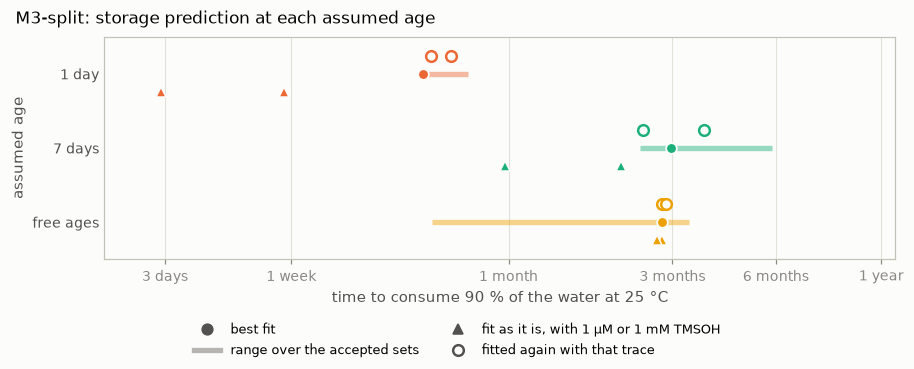

In [21]:
storage, seeded = read('prediction_storage.csv'), read('prediction_storage_traces.csv')
fit_plots.plot_storage_ranges(storage, seeded, structure=MAIN, scenarios=FITTING);
days = storage[storage['structure'] == MAIN].set_index('scenario').loc[list(FITTING)].rename(index=AGES)
display(pd.DataFrame({'best fit (days)': (days['t90 water (h), best fit'] / 24).round(0), 'accepted sets, from (days)': (days['band low (h)'] / 24).round(0),
                      'to (days)': (days['band high (h)'] / 24).round(0), 'TMSPA left after 1 year': days['TMSPA left after 1 year, best fit'].round(2)})
        .rename_axis('assumed age'))
seeded = seeded[(seeded['structure'] == MAIN) & seeded['scenario'].isin(FITTING)].assign(age=lambda d: d['scenario'].map(AGES), trace=lambda d: d['TMSOH at mixing (M)'].map(show_M))
(seeded.set_index(['age', 'trace'])[[c for c in seeded.columns if c.startswith('t90')]] / 24).round(0).rename(columns=lambda c: c.replace('t90 water (h), ', '')).rename_axis(
    index=['assumed age', 'TMSOH at mixing'], columns='days to consume 90 % of the water')

**Result**

- **Best fits:** 90 % of the water is gone after 17 days (1 day), 89 days (7 days) or 84 days (free ages). Over the accepted sets: 17–23, 72–176 and 18–100 days. Together that is between 2½ weeks and 6 months, a factor of ten.
- **The common-age numbers move with a trace of TMSOH.** The 1-day fit gives 17 days from the recipe alone, 7 days with 1 µM and 3 days with 1 mM. The 7-day fit gives 89, 64 and 29 days. The free-age fit stays at 81–86 days in every case.
- **After one year about a quarter of the TMSPA is left at every age (0.26–0.28).** This is set by the amount of water (20 mM for 50 mM TMSPA) and the fitted energies, not by the barriers. It is the most stable number here.
- **What the prediction rests on:** barriers seen at 22 °C in two water samples of unknown age, applied at 25 °C to a recipe with 13 to 50 times less water.

--> The storage time is known to a factor of ten. The amount of TMSPA left at the end is known better than the time it takes.

### 5.2 Peter's protocol and the temperature

- **Case:** the protocol holds the sample at 20, 30, … 80 °C and records a spectrum after each hold. The question is how much TMSPA is left at each one.
- **Blind spot:** hydrolysis and transfer were seen at 22 °C only, and every fit sets ΔS‡ = 0. Here the best fit is rerun with ΔS‡ from −150 to +50 J mol⁻¹ K⁻¹, each barrier anchored at the temperature where it was observed.

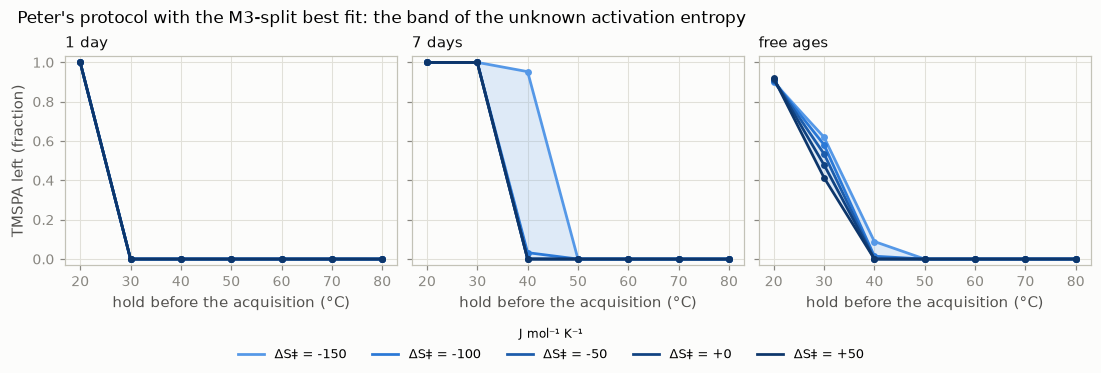

In [22]:
protocol = read('prediction_protocol.csv')
fit_plots.plot_protocol_band(protocol, structure=MAIN, scenarios=FITTING, labels=fit_plots.AGE_LABELS);

**Result**

- **The assumed age decides the prediction, not the activation entropy.**
  - 1-day fit: all TMSPA is there at 20 °C and none at 30 °C, for every ΔS‡. The cliff of 3.3 falls between the two.
  - 7-day fit: all TMSPA survives 20 and 30 °C and is gone at 50 °C. ΔS‡ only decides the 40 °C point.
  - Free ages: 0.90–0.92 is left at 20 °C, 0.41–0.62 at 30 °C and 0–0.09 at 40 °C.
- **The band of ΔS‡ is narrow because TMSPA is gone close to where the barriers were measured.** All three fits consume it by 40–50 °C, within 20–30 K of 22 °C. Over that range the declared ΔS‡ changes a barrier by at most 0.03–0.05 eV.
- **The temperature blind spot is elsewhere.** At the 60–80 °C holds the fits act only through condensation and solvent attack, on a mixture that has already reacted. Hydrolysis and transfer at 60–80 °C are never tested.
- **Against `peter_reference`:** 1.15 eV spreads the consumption of TMSPA over the 20–80 °C holds by construction. No fit here does: each consumes it within one or two holds.

--> Both predictions inherit the open question of §4: how TMSPA is consumed.

## 6. What is known, what is not

**The ladder** (2.6)**:** only M3-split fits, at 1 day, 7 days and with free ages. It needs R1 separate from R2–R3 and the energies of R1–R4 free, together.

**Known: the same at every age, with or without a trace, and under every declared variant** (§4.8)

- **Solvent attack:** ΔG‡(R8) = 1.29 eV at 80 °C (1.28–1.30; ±0.02 more if the glovebox hold was 4 h or 16 h).
- **Condensation:** ΔG‡(R4) = 1.24 eV at 80 °C (1.22–1.28, same remark). It falls to 1.18 eV when the glovebox or the 2 % sample is left out.
- **Second and third hydrolysis:** ΔG‡(R2) = 0.92–1.05 eV and ΔG‡(R3) = 0.94–1.07 eV at 22 °C.
- **Energies of R2 and R3:** above the computed values, close to zero, if all the added water was available.
- **Structure:** no single barrier, and no barrier per family with the computed energies, describes the samples.

**Not known**

| Open point | Why it is open | What would close it |
|---|---|---|
| How TMSPA is consumed: ΔG‡(R1) 1.08–1.69 eV, ΔG‡(R5) 0.41–0.99 eV | the sample ages and the TMSOH present at mixing decide (3.3, 4.2) | one sample followed in time at 22 °C from a known mixing time |
| Whether the 2 % sample rests at an equilibrium or ran out of water | any available fraction from 0.2 to 1 fits (4.5) | the water content of the sample, which no spectrum here measures |
| The temperature dependence of hydrolysis and transfer | seen at 22 °C only (5.2) | the same recipe at a second temperature |
| The shape of the barrier relation | the reactions seen are close to thermoneutral, where Marcus and Agmon–Levine coincide (4.6) | not testable with these samples |
| Whether any barrier except solvent attack is right | each of the others rests on one sample, or moves when one is left out (4.4) | a second sample for each reaction |

**Decisions left to the author**

- **A fitted model in the registry.** By the rule fixed before fitting, the first consistent set is M3-split at a common age: 7 days (χ² 19.8) by the lower χ², 1 day (20.4) just behind. Nothing was written into the registry, because both rest on the waiting time that a trace removes (4.2) and the free-age set fails TMSPa alone (4.7). `build_fitted_model` builds any of them from its result file.

**Audit that needs the raw spectra**

- The ³¹P region near −144 ppm (PF₆⁻) in every TMSPa sample, not only the 0.5 % one.
- The ¹⁹F spectrum of the glovebox TMSOH sample.
- The clock times and durations of the heating steps of the 2 % sample (18 min assumed, 8 h stated in the paper; 4.6 shows what changes).

**Left for later**

- TMSPa without added water as a fitted sample, with its water content as a parameter: 4.7 shows that it separates the fits.
- Rate-law variants, condensation from ¹H, sampling of the parameter space, gas evolution at 60–80 °C.

---

## Appendix: complete tables

Reference material behind the steps above, with the scenario names of the result files (`short` = 1 h, `middle` = 1 day, `long` = 7 days, `free` = free ages).

### A.1 Every structure at every age, and its fitted parameters

A cell of the first table reads χ² (worst miss). The second table gives the fitted parameters themselves: the intrinsic barriers g (eV), the shifts of ΔG_rxn (eV) and the age of the 2 % sample (log₁₀ of hours) where it is free.

In [23]:
ordered = summary.assign(structure=pd.Categorical(summary['structure'], LADDER)).sort_values('structure')
display(tables.format_structure_table(ordered.assign(structure=ordered['structure'].astype(str))))
parameters.set_index(['structure', 'scenario']).reindex([(s, sc) for s in LADDER for sc in AGES]).round(3).fillna('—')

"χ² (largest |z|), ✓ = no |z| above 3",free parameters,short,middle,long,free
M0-BEP,1 (+1 age if free),3634 (60.1) ✗,3634 (60.1) ✗,3630 (60.0) ✗,3630 (60.0) ✗
M0-Marcus,1 (+1 age if free),3690 (59.8) ✗,3687 (59.7) ✗,3670 (59.4) ✗,3670 (59.4) ✗
M1,4 (+1 age if free),1067 (20.1) ✗,343 (16.1) ✗,320 (16.0) ✗,301 (16.0) ✗
M1-split,5 (+1 age if free),1021 (20.1) ✗,301 (16.0) ✗,291 (15.4) ✗,282 (15.0) ✗
M3,8 (+1 age if free),536 (11.6) ✗,294 (16.1) ✗,60 (4.1) ✗,27 (3.1) ✗
M3-split,9 (+1 age if free),535 (11.6) ✗,20 (1.9) ✓,20 (1.9) ✓,19 (1.9) ✓


g all reactions log10 age 2 % H2O g hydrolysis g transfer  \
structure scenario                                                             
M0-BEP    short              1.279                 —            —          —   
          middle             1.278                 —            —          —   
          long               1.276                 —            —          —   
          free               1.276             2.225            —          —   
M0-Marcus short              1.469                 —            —          —   
          middle             1.468                 —            —          —   
          long                1.46                 —            —          —   
          free                1.46             2.225            —          —   
M1        short                  —                 —         0.94      1.021   
          middle                 —                 —         1.41       0.81   
          long                   —                 —        1.397      0.701   
          free                   —             2.225        1.315      0.904   
M1-split  short                  —                 —            —        1.5   
          middle                 —                 —            —      0.988   
          long                   —                 —            —      1.035   
          free                   —             2.225            —      1.036   
M3        short                  —                 —        0.872      0.648   
          middle                 —                 —        1.421      0.661   
          long                   —                 —          1.7      0.786   
          free                   —             2.225        1.684      0.601   
M3-split  short                  —                 —            —       0.65   
          middle                 —                 —            —      0.646   
          long                   —                 —            —      0.657   
          free                   —             2.225            —      0.996   

                   g condensation g solvent_attack g hydrolysis_R1  \
structure scenario                                                   
M0-BEP    short                 —                —               —   
          middle                —                —               —   
          long                  —                —               —   
          free                  —                —               —   
M0-Marcus short                 —                —               —   
          middle                —                —               —   
          long                  —                —               —   
          free                  —                —               —   
M1        short             1.125            1.306               —   
          middle            1.032            1.305               —   
          long              1.091            1.305               —   
          free              1.104            1.306               —   
M1-split  short             1.128            1.306            1.14   
          middle             1.13            1.306           1.458   
          long              1.214            1.309           1.402   
          free              1.262            1.308           1.314   
M3        short             1.349             1.31               —   
          middle            1.053            1.307               —   
          long              1.038            1.305               —   
          free              1.009            1.307               —   
M3-split  short              1.35             1.31           0.894   
          middle            1.268             1.31           1.493   
          long              1.232             1.31           1.449   
          free              1.329             1.31           1.109   

                   g hydrolysis_R23  dG R1  dG R2  dG R3  dG R4  
structure scenario                                 

### A.2 Every miss of every structure

All 45 values (49 with the freed energies) at 1 day and with free ages. The number is the miss z; bold where it is above 3. The "no change" rows show the largest of each peak.

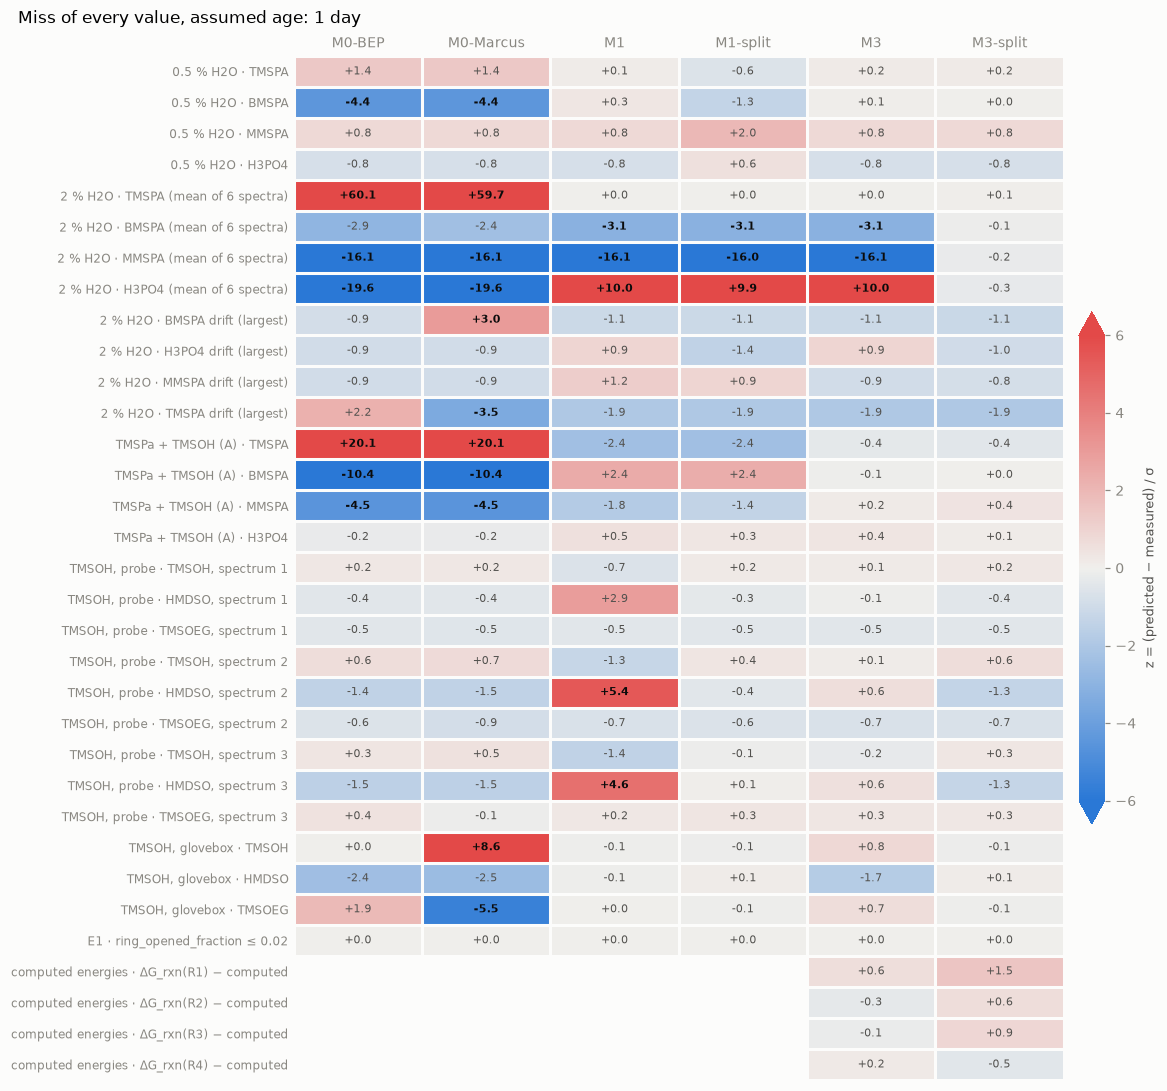

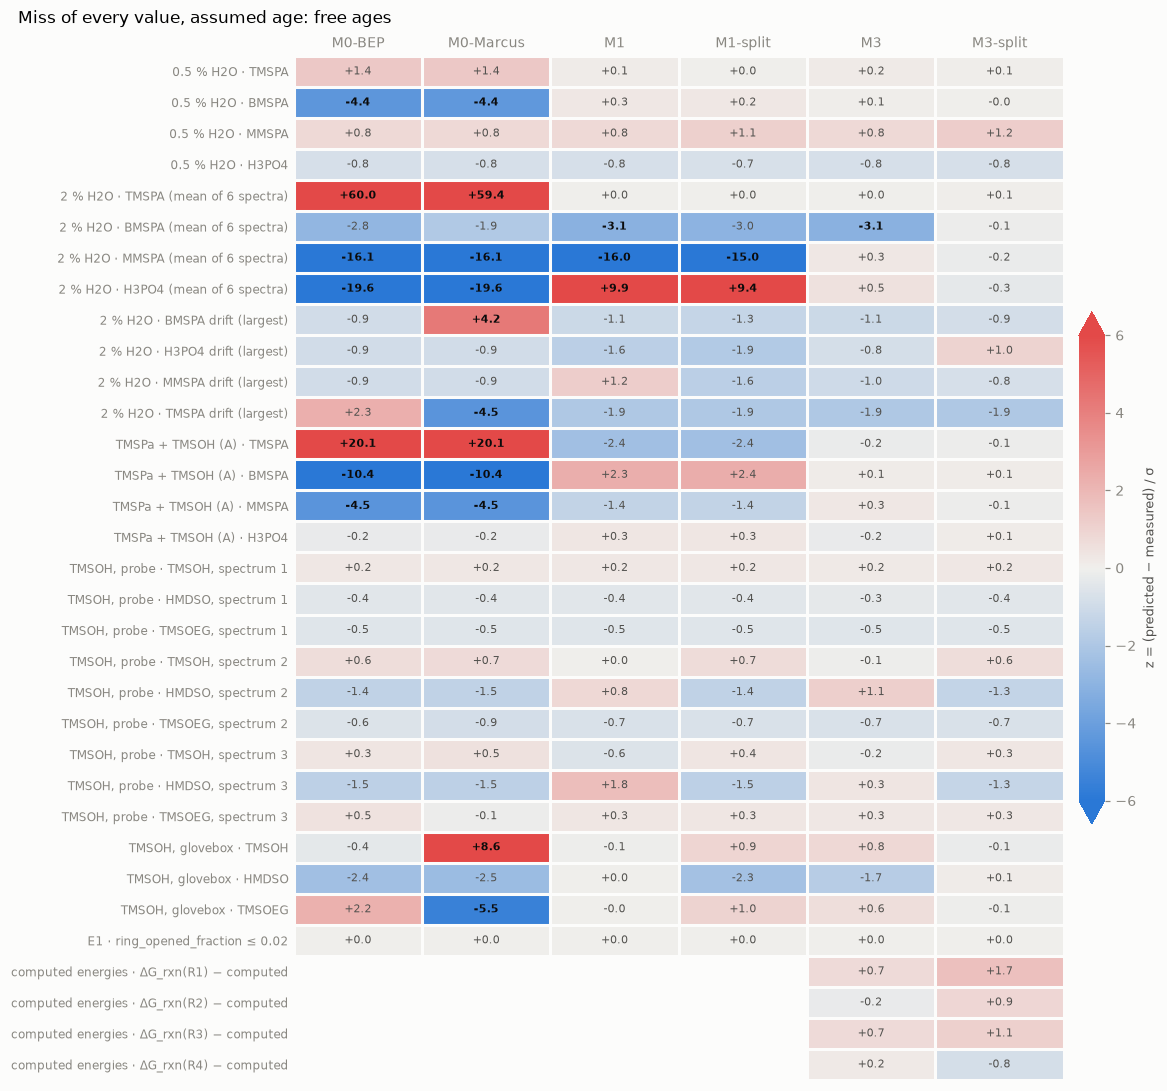

In [24]:
for scenario in ('middle', 'free'):
    fit_plots.plot_residual_map(residuals, scenario=scenario, order=LADDER, title=f'Miss of every value, assumed age: {AGES[scenario]}')

### A.3 Intervals of the fitted parameters

95 % profile intervals of the parameters of M3-split as they are fitted (g and the shifts of ΔG_rxn), and the profiles they are read from. A side on which the profile never rises by 3.84 inside its grid is left open. §4.3 gives the same information per reaction, as ΔG‡ and ΔG_rxn.

M3-split: 95 % interval,short,middle,long,free
dG R1,≥ 0.557,≥ 0.342,0.295–0.658,0.313–0.652
dG R2,0.202–0.382,0.130–0.271,0.083–0.397,0.099–0.416
dG R3,0.208–0.385,0.179–0.451,0.174–0.483,0.181–0.471
dG R4,-0.573–-0.148,≤ -0.064,≤ -0.049,≤ -0.077
g condensation,1.268–1.515,1.210–1.349,1.201–1.518,1.215–1.532
g hydrolysis_R1,0.833–0.972,≥ 1.218,not determined,0.998–1.175
g hydrolysis_R23,0.820–0.899,0.900–0.978,0.890–1.029,0.891–1.048
g solvent_attack,1.298–1.327,1.298–1.326,1.297–1.327,1.298–1.325
g transfer,≤ 0.779,≤ 0.840,≤ 0.914,≤ 1.067
log10 age 2 % H2O,—,—,—,≥ 1.70


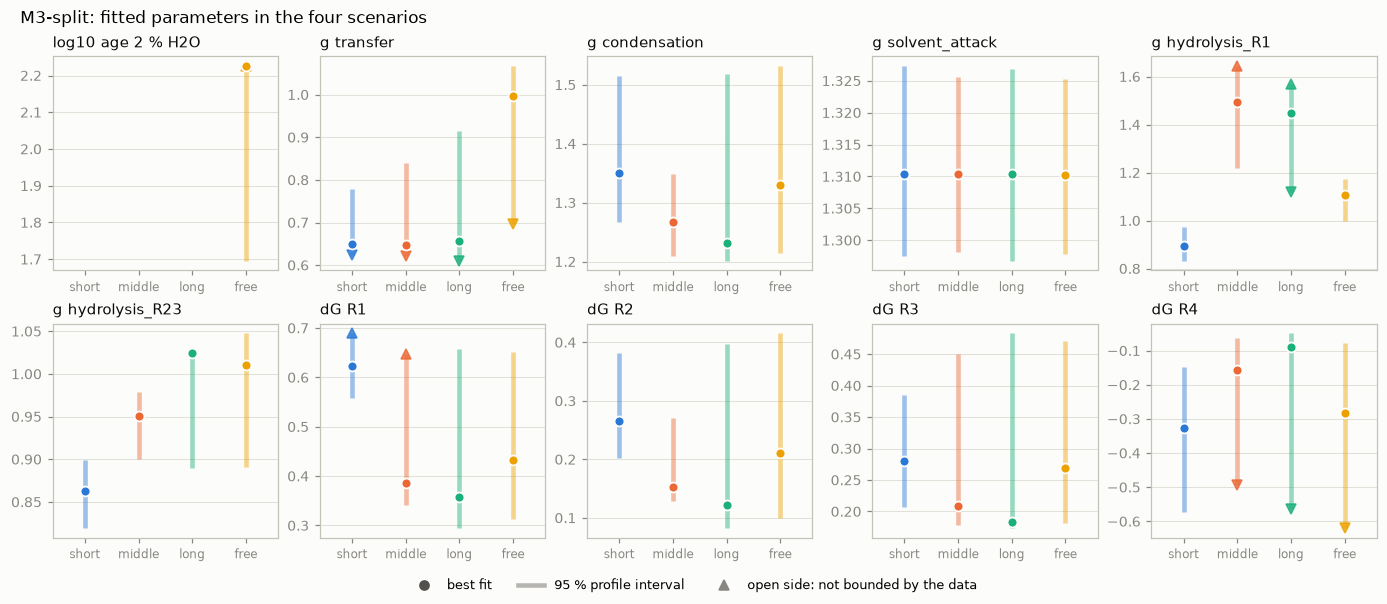

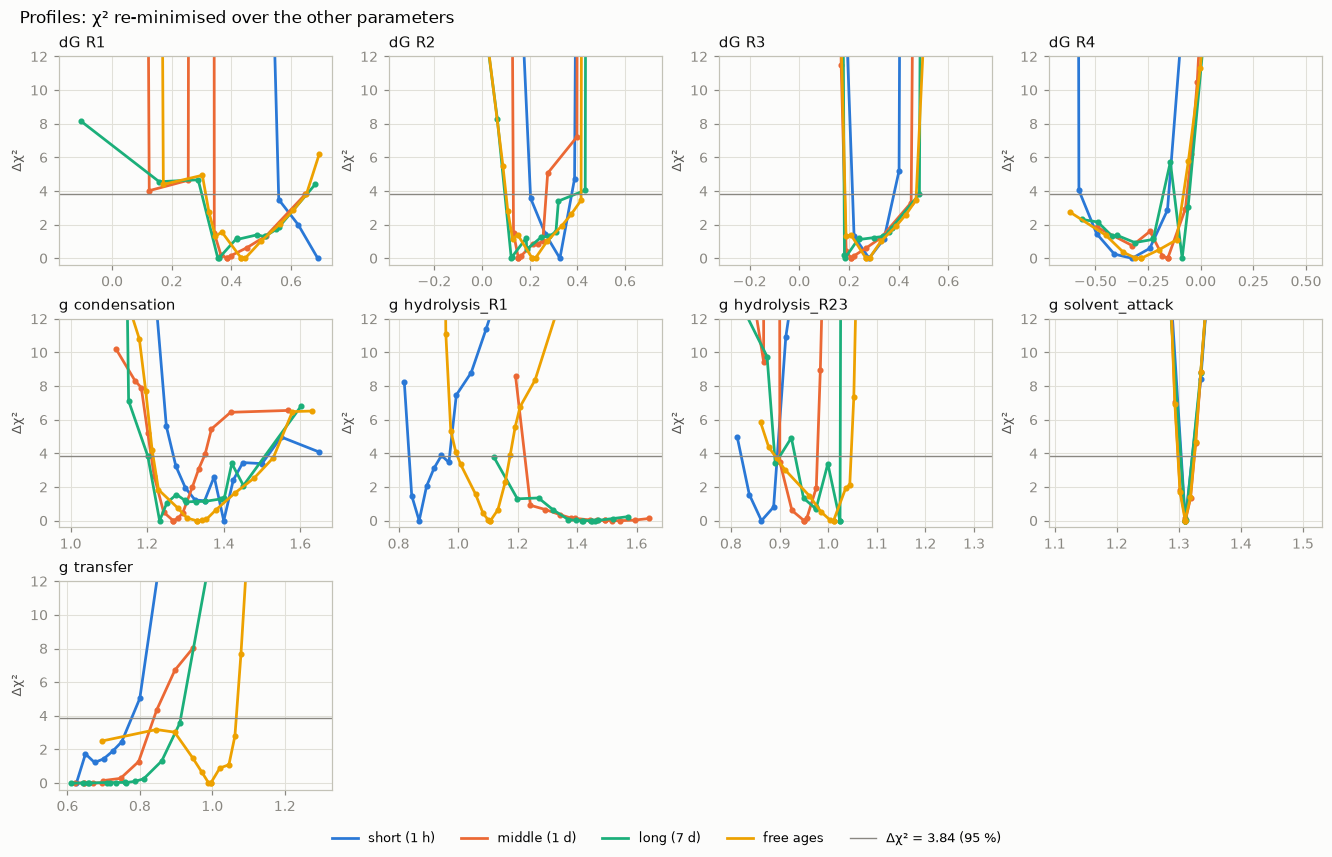

In [25]:
intervals = read('intervals.csv')
display(tables.format_interval_table(intervals, MAIN).rename_axis(f'{MAIN}: 95 % interval', axis=1))
fit_plots.plot_fit_across_scenarios(parameters, intervals, structure=MAIN);
fit_plots.plot_profiles({scenario: load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))['profile'] for scenario in AGES});

### A.4 Combinations of parameters that the data see

Each row is one combination of the parameters of M3-split at the best fit, with the standard error the data give along it. Large values are directions the data do not determine. These are statements at the best fit only; the profiles of A.3 hold away from it.

- **1 day:** one combination is held to 0.13 meV: the barrier of R2–R3 together with ΔG_rxn(R2), which is the timing of the cliff against the single spectrum of the 0.5 % sample. It says how sharply this fit depends on that spectrum, not how precisely anything was measured. One combination of the R1 and transfer barriers is not held at all.
- **Free ages:** eight combinations are held to 2–24 meV. The ninth (394 meV) moves the four reaction energies together and is held by the computed values alone.

In [26]:
def show_meV(value_eV):
    return 'over 1 000' if value_eV > 1.0 else f'{1000 * value_eV:.1f}'


for scenario in ('middle', 'free'):
    directions = load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))['directions']
    display(directions.drop(columns='sigma_eV').round(2).set_index(directions['sigma_eV'].map(show_meV).rename(f'{AGES[scenario]}: standard error along the combination (meV)')))

,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
1 day: standard error along the combination (meV),,,,,,,,,
0.1,-0.08,-0.97,-0.06,-0.00,-0.00,-0.04,-0.21,-0.05,0.03
2.3,-0.00,-0.04,-0.00,0.01,0.00,-0.00,0.01,0.91,0.41
6.7,-0.00,0.00,-0.00,-0.01,1.00,0.00,-0.01,0.00,-0.01
7.2,-0.01,0.17,-0.01,-0.04,-0.01,0.26,-0.90,0.13,-0.26
12.8,0.01,-0.04,0.01,-0.86,-0.02,-0.20,0.12,0.18,-0.41
17.6,-0.05,0.07,-0.04,0.29,0.00,-0.91,-0.19,0.09,-0.20
37.0,0.48,-0.14,0.36,0.35,-0.00,0.17,0.21,0.26,-0.60
228.6,-0.63,0.00,-0.48,0.22,-0.00,0.20,0.21,0.19,-0.45
over 1 000,-0.60,0.00,0.80,-0.00,0.00,-0.00,-0.00,-0.00,0.00


,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
free ages: standard error along the combination (meV),,,,,,,,,
2.1,-0.01,-0.13,0.06,-0.00,0.00,-0.00,-0.03,-0.89,-0.44
6.1,-0.10,-0.84,0.50,0.01,0.03,-0.08,-0.01,0.11,0.10
6.7,0.01,0.02,-0.01,-0.02,1.00,0.01,-0.00,0.00,-0.01
7.3,-0.67,0.09,-0.08,0.02,0.01,-0.59,0.42,-0.07,0.09
8.3,-0.45,-0.02,-0.13,-0.06,-0.01,-0.12,-0.82,0.15,-0.26
13.1,-0.07,-0.03,-0.12,0.89,0.02,0.07,-0.16,-0.18,0.35
18.5,0.08,-0.49,-0.82,-0.19,-0.00,-0.00,0.04,-0.07,0.16
23.7,0.54,-0.04,-0.05,0.24,0.00,-0.72,-0.07,0.16,-0.31
394.2,0.19,0.14,0.16,-0.33,-0.00,-0.33,-0.34,-0.34,0.69


### A.5 Protocol prediction as numbers, and the solver tolerance

TMSPA left at each hold of Peter's protocol for each ΔS‡ (§5.2), and two profile intervals repeated at a tighter solver tolerance: the edges move by at most 0.005 eV.

In [27]:
display(protocol[protocol['structure'] == MAIN].pivot_table(index=['scenario', 'dS (J/mol/K)'], columns='hold T (°C)', values='TMSPA left').loc[list(FITTING)].round(3))
read('tolerance_check.csv').round(4)

hold T (°C)             20.0   30.0   40.0  50.0  60.0  70.0  80.0
scenario dS (J/mol/K)                                             
middle   -150.0        1.000  0.000  0.000   0.0   0.0   0.0   0.0
         -100.0        1.000  0.000  0.000   0.0   0.0   0.0   0.0
         -50.0         1.000  0.000  0.000   0.0   0.0   0.0   0.0
          0.0          1.000  0.000  0.000   0.0   0.0   0.0   0.0
          50.0         1.000  0.000  0.000   0.0   0.0   0.0   0.0
long     -150.0        1.000  1.000  0.953   0.0   0.0   0.0   0.0
         -100.0        1.000  1.000  0.033   0.0   0.0   0.0   0.0
         -50.0         1.000  1.000  0.001   0.0   0.0   0.0   0.0
          0.0          1.000  1.000  0.000   0.0   0.0   0.0   0.0
          50.0         1.000  1.000  0.000   0.0   0.0   0.0   0.0
free     -150.0        0.899  0.620  0.089   0.0   0.0   0.0   0.0
         -100.0        0.904  0.581  0.015   0.0   0.0   0.0   0.0
         -50.0         0.910  0.535  0.001   0.0   0.0   0.0   0.0
          0.0          0.915  0.479  0.000   0.0   0.0   0.0   0.0
          50.0         0.920  0.414  0.000   0.0   0.0   0.0   0.0

,parameter,"low, rtol 1e-6","low, rtol 1e-8","high, rtol 1e-6","high, rtol 1e-8","status, rtol 1e-6","status, rtol 1e-8"
0,g solvent_attack,1.2982,1.2982,1.3255,1.3255,interval,interval
1,g hydrolysis_R23,0.9004,0.9050,0.9784,0.9784,interval,interval
